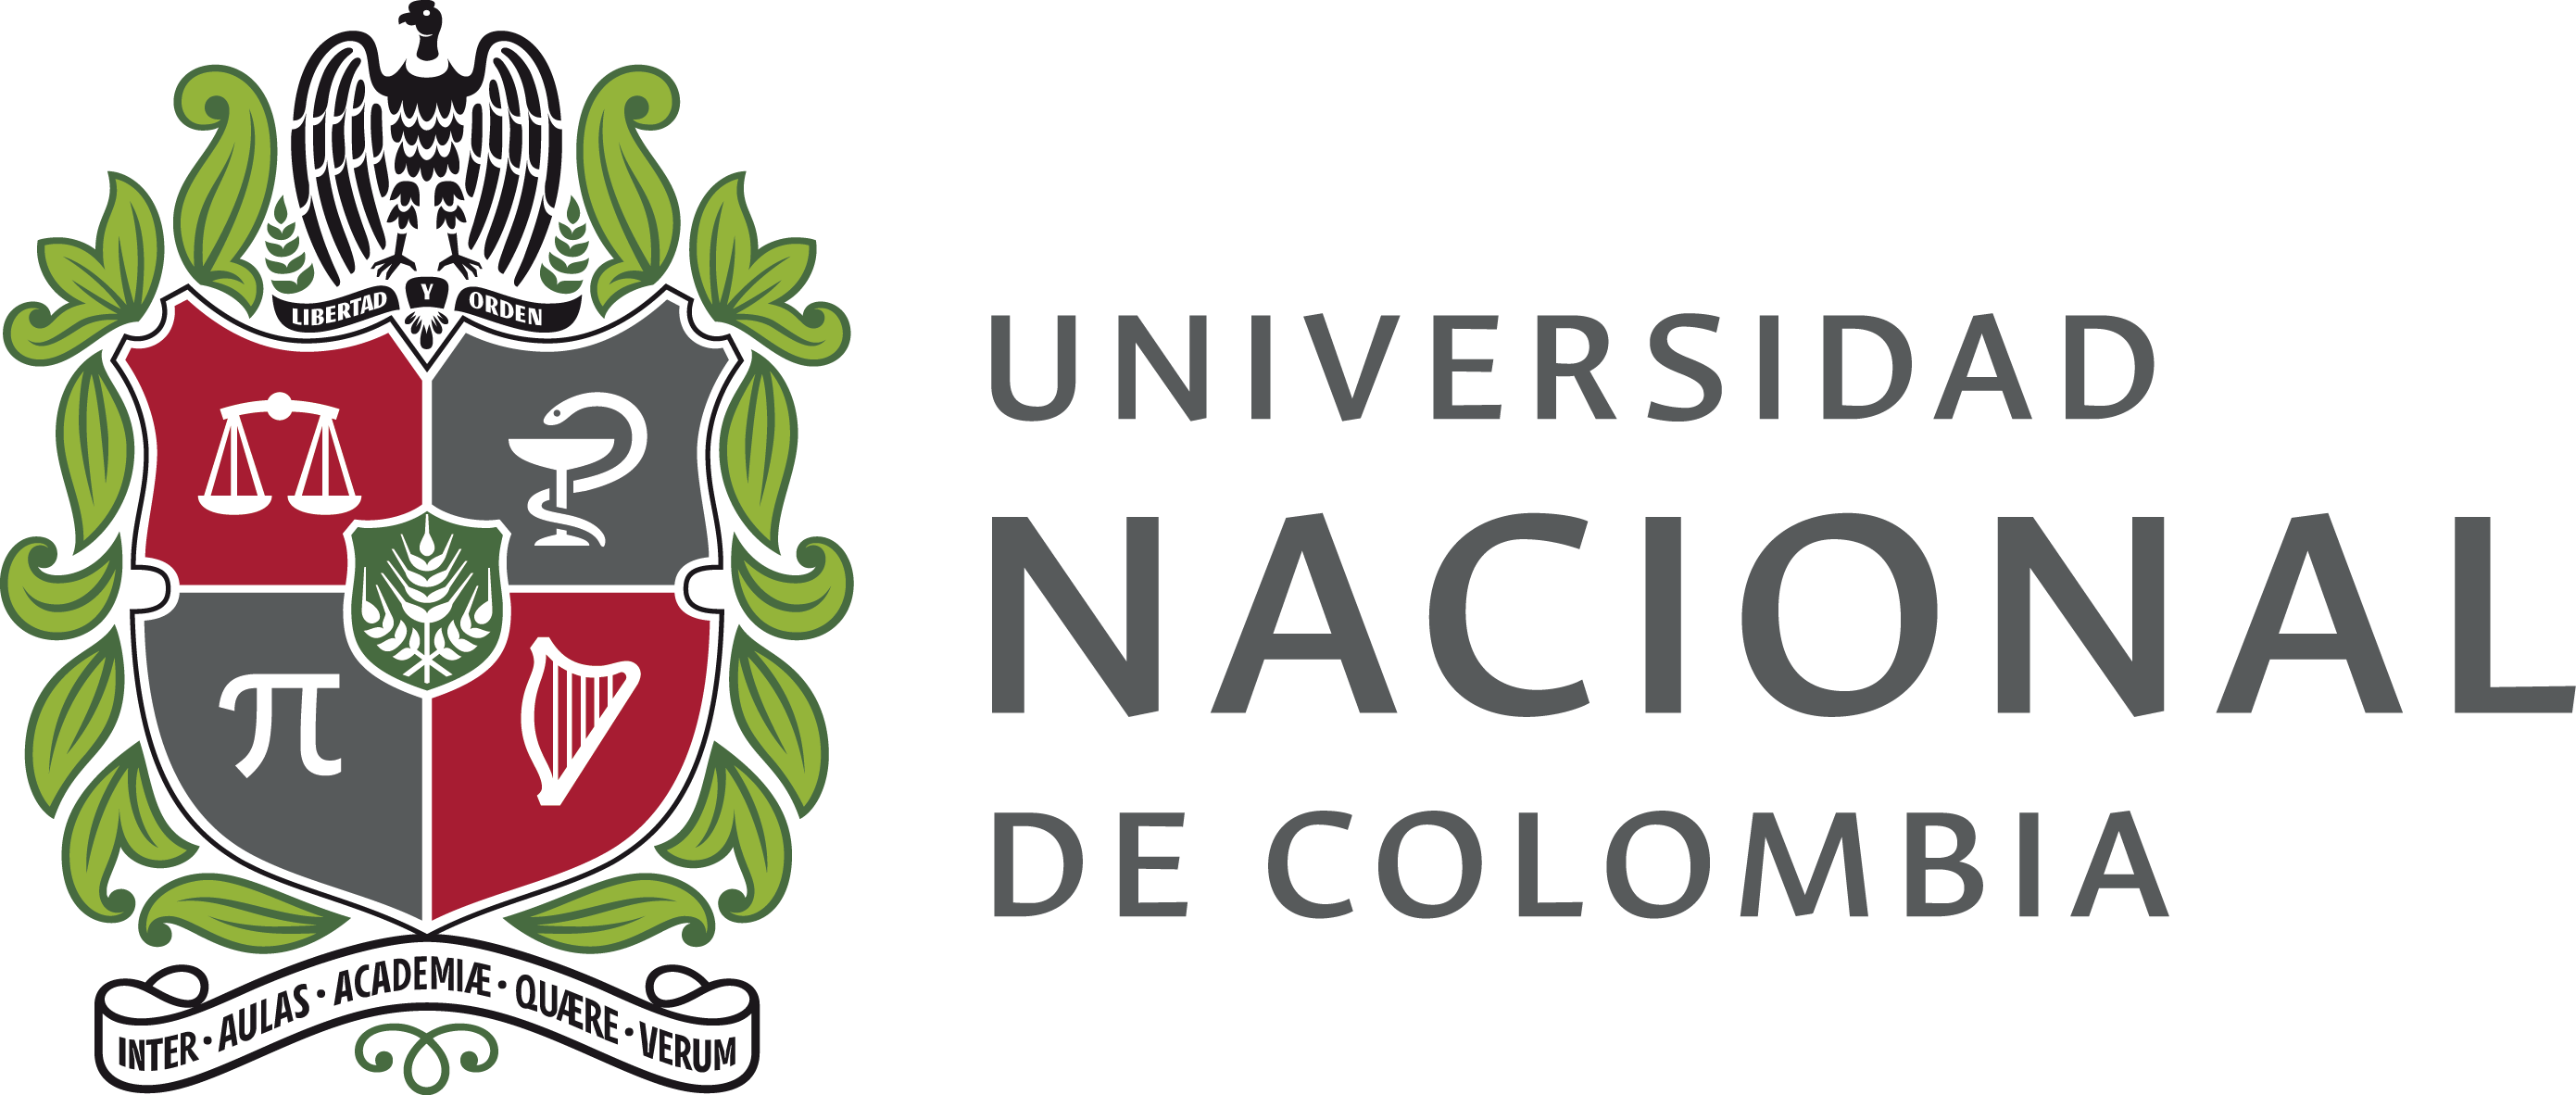
### **Universidad Nacional de Colombia sede Manizales**
#### Facultad de ingeniería y arquitectura
#### Departamento de ingeniería eléctrica, electrónica y computación
#### *Procesamiento digital de imágenes*

#### Profesor: Lucas Iturriago

## Segmentación de imágenes

### 13.1 Concepto central

La segmentación convierte la predicción en algo **espacialmente denso**:
en lugar de producir una sola clase global, el modelo genera una **distribución de probabilidad por píxel**.

Formalmente:
$$
f_\theta: \mathbb{R}^{H \times W \times 3} \rightarrow \mathbb{R}^{H \times W \times C}
$$
donde:

* $H, W$: alto y ancho de la imagen,
* $C$: número de clases posibles,
* $f_\theta$: red convolucional parametrizada por $\theta$.

Cada salida $f_\theta(x)_{i,j}$ es un vector de probabilidades que indica la clase del píxel $(i,j)$.

#### Tipos de segmentación

| Tipo                           | Descripción                                                                          | Ejemplo ilustrativo                                              |
| ------------------------------ | ------------------------------------------------------------------------------------ | ---------------------------------------------------------------- |
| **Segmentación semántica**     | Clasifica cada píxel según su categoría, **sin distinguir instancias individuales**. | Todos los píxeles que pertenecen a un “gato” son marcados igual. |
| **Segmentación de instancias** | Además de la clase, el modelo **diferencia entre objetos individuales**.             | Gato 1, Gato 2, etc.                                             |
| **Segmentación panóptica**     | Combina semántica e instancias: da una vista completa y coherente de la escena.      | Cada píxel tiene clase + identificador único.                    |

#### Flujo general de una CNN para clasificación de imágenes

1. **Entrada**

   * Imagen $X \in \mathbb{R}^{H\times W\times 3}$.

2. **Encoder (extracción de características, “contracción”)**

   * Bloques Conv → BN → ReLU → Pool (o Conv con stride>1).
   * Objetivo: aprender representaciones jerárquicas (bordes → texturas → partes).
   * Resultado: mapas de características con menor resolución espacial y mayor profundidad $F_{enc}$ ej. $H/32 \times W/32 \times D$.

3. **Bottleneck (contexto global)**

   * Capas profundas o convoluciones atrous/dilated para aumentar el *receptive field* sin reducción de resolución adicional.
   * Opcional: mecanismos de contexto (ASPP, attention) para capturar información multi-escala.

4. **Decoder (reconstrucción, “expansión”)**

   * Operaciones de upsampling (transposed conv / bilinear upsample + conv) que incrementan la resolución espacial gradualmente.
   * En cada etapa suelen concatenarse o sumar las **skip connections** desde la capa correspondiente del encoder para recuperar detalle fino.
   * Resultado: mapas de características con resolución intermedia, acercándose a (H\times W).

5. **Capa final (predicción por píxel)**

   * Convolución $1\times 1$ que reduce la profundidad a $C$ clases → logits por píxel.
   * Softmax (pixel-wise) para obtener probabilidades $\hat{Y} \in [0,1]^{H\times W \times C}$.
   * Máscara final: $\text{argmax}*c \hat{Y}*{i,j,c}$ → $H\times W$ entero.

### 13.2 Arquitecturas representativas para segmentación de imágenes

#### Fully Convolutional Networks (FCN)

Antes de 2015, las CNN se usaban casi exclusivamente para **clasificación de imágenes** (AlexNet, VGG, GoogLeNet).
El reto era extenderlas a tareas donde **cada píxel** debía clasificarse (segmentación).
El trabajo seminal de *Long, Shelhamer y Darrell (CVPR 2015)* propuso reemplazar las capas totalmente conectadas (FC) de redes clasificadoras por **capas convolucionales**, creando así las **Fully Convolutional Networks (FCN)**.

##### Estructura general

![FCN-8 Arquitectura](https://www.researchgate.net/publication/348497401/figure/fig2/AS:980184966635522@1610705715370/FCN-8s-architecture-35.ppm)

Una FCN convierte una red de clasificación (p. ej., VGG16) en un modelo denso por píxel:

```
Imagen (H×W×3)
 ↓
Encoder (Conv + Pool)  → extracción de características (H/32×W/32×D)
 ↓
Upsampling (Transposed Convolution)
 ↓
Mapa de etiquetas (H×W×C)
```

* El **encoder** es la parte convolucional de una red preentrenada (VGG o ResNet).
* El **decoder** utiliza *transposed convolutions* (o deconvolutions) para **recuperar la resolución espacial**.
* Se añaden **skip connections** desde capas intermedias del encoder (p. ej., FCN-8s, FCN-16s) para mezclar información semántica profunda con detalles espaciales finos.

##### Innovaciones técnicas

* Eliminación total de capas densas → red **totalmente convolucional**, capaz de procesar imágenes de cualquier tamaño.
* Uso de **upsampling aprendido** (transposed conv) en lugar de interpolación manual.
* **Skip connections jerárquicos**, pioneros de las arquitecturas encoder–decoder.

#### U-Net

Desarrollada para **segmentación biomédica** (microscopía celular), la U-Net mejoró el flujo encoder–decoder de la FCN mediante una estructura **simétrica y eficiente**, ideal para conjuntos de datos pequeños.

##### Estructura general

![UNet arquitectura](https://media.geeksforgeeks.org/wp-content/uploads/20220614121231/Group14.jpg)

U-Net tiene forma de **“U”**, con un encoder que reduce la resolución y un decoder que la reconstruye.

```
Encoder (contracción)
  ↓
[Conv 3×3 + ReLU + Pool] × N
  ↓
Bottleneck
  ↓
[Upsample + Conv 3×3 + ReLU] × N
  ↓
Decoder (expansión)
```

* Cada etapa del decoder **concatena** los mapas de activación del encoder correspondiente (skip connections).
* Esto **recupera detalles espaciales** que se habían perdido por el pooling.
* La última capa aplica una **convolución 1×1** para obtener la máscara final.

##### Innovaciones técnicas

* **Skip connections concatenativos**: no solo suman información (como en FCN), sino que **preservan texturas completas**.
* **Simetría estructural** → balance entre contexto y precisión local.
* **Uso eficiente de datos**: se puede entrenar desde cero con pocos ejemplos gracias a fuertes *data augmentations* (rotaciones, elastic distortions, flips).

#### DeepLab (v1–v3+)

Mientras FCN y U-Net avanzaban en estructura, persistía un problema: el **receptive field** limitado y la pérdida de detalle por *downsampling*.
DeepLab, de Google Research, abordó este reto mediante el uso de **convoluciones dilatadas** (*atrous convolutions*) y **módulos multiescala**.

##### Estructura general

![DeepLabV3+ Arquitectura](https://www.researchgate.net/profile/Mma-Hashem/publication/354108791/figure/fig2/AS:1060541816643585@1629864281309/Architecture-of-DeepLabV3-with-backbone-network.png)

DeepLab mantiene un encoder basado en ResNet, pero modifica sus convoluciones y agrega módulos especializados:

```
Imagen
 ↓
Backbone (ResNet con atrous conv)
 ↓
ASPP (Atrous Spatial Pyramid Pooling)
 ↓
Upsample + 1×1 conv
 ↓
Predicción por píxel (H×W×C)
```

* **Atrous convolutions** → amplían el campo receptivo sin aumentar parámetros ni reducir resolución.
* **ASPP module** → combina varias atrous convoluciones con diferentes tasas de dilatación (captura multi-escala).
* **DeepLabv3+** (2018) añade un **decoder liviano** con skip connections de baja capa para refinar bordes.

##### Innovaciones técnicas

* **Atrous convolutions:** reemplazan pooling por dilatación → mejor contexto sin pérdida espacial.
* **ASPP:** integración explícita de múltiples escalas de observación.
* **DeepLabv3+:** integra lo mejor de FCN (up-sampling aprendido) y U-Net (skip connections).
* Uso de **preentrenamiento ImageNet** + **entrenamiento fine-tuned** con datasets de segmentación (PASCAL VOC, Cityscapes).

#### Resumen general

| Arquitectura      | Año       | Principales innovaciones                                                               | Limitaciones                                          |
| ----------------- | --------- | -------------------------------------------------------------------------------------- | ----------------------------------------------------- |
| **FCN**           | 2015      | Primer modelo totalmente convolucional; upsampling aprendido; skip connections básicos | Bordes imprecisos, poco contexto                      |
| **U-Net**         | 2015      | Estructura simétrica, concatenación de features, eficiente con pocos datos             | Requiere ajustar hiperparámetros por tamaño de imagen |
| **DeepLab (v3+)** | 2017–2018 | Atrous convolutions, ASPP, skip refinado, backbone potente                             | Mayor complejidad y demanda computacional             |

### 13.3 Funciones de pérdida para segmentación de imágenes

En la segmentación de imágenes, la **función de pérdida** mide qué tan diferente es la máscara predicha respecto a la máscara real.
A diferencia de la clasificación de imágenes (donde se evalúa una sola etiqueta), aquí **cada píxel** es una predicción individual, lo que hace que la pérdida deba reflejar tanto **exactitud local** como **coherencia espacial**.

#### Cross-Entropy Loss (Pérdida de entropía cruzada)

##### Definición

La **Cross-Entropy (CE)** mide la disimilitud entre la distribución de probabilidad predicha y la real (ground truth).
En segmentación semántica multiclase, se aplica **por píxel**, comparando el vector de probabilidades $p_i$ con la etiqueta real $y_i$.


$$
\mathcal{L}*{CE} = - \frac{1}{N} \sum*{i=1}^{N} \sum_{c=1}^{C} y_{i,c} \log(p_{i,c})
$$

donde:

* $N$: número de píxeles,
* $C$: número de clases,
* $y_{i,c} \in {0,1}$: indica si el píxel $i$ pertenece a la clase $c$,
* $p_{i,c}$: probabilidad predicha para la clase $c$ en el píxel $i$.

##### Consideraciones

* Muy estable y ampliamente usada en redes como **U-Net** o **DeepLab**.
* Tiende a **favorecer clases dominantes** (si hay desbalance).
* Requiere que las salidas pasen por un *Softmax* (multiclase) o *Sigmoid* (binaria).

#### Dice Loss (Coeficiente de Sørensen–Dice)

##### Definición

El **Dice Loss** mide la similitud entre conjuntos, es decir, cuán grande es la intersección entre predicción y máscara real.
Es ideal para casos con **alto desbalance de clases**, ya que se enfoca en el **solapamiento relativo**.

$$
\mathcal{L}_{Dice} = 1 - \frac{2 \sum_i p_i y_i + \epsilon}{\sum_i p_i + \sum_i y_i + \epsilon}
$$

donde:

* $p_i$: probabilidad predicha del píxel $i$,
* $y_i$: valor real (0 o 1),
* $\epsilon$: término pequeño para evitar división por cero.

##### Consideraciones

* Enfocado en **superficie y forma** → útil en segmentación médica.
* Puede ser **inestable** si las máscaras son muy pequeñas (pequeños objetos).
* Se puede aplicar por clase y luego promediar (en problemas multiclase).

####  Tversky Loss

El **Tversky Loss** es una generalización del Dice, que introduce pesos diferentes para **falsos positivos (FP)** y **falsos negativos (FN)**, controlando el equilibrio entre sensibilidad y precisión.

$$
\mathcal{L}_{Tversky} = 1 - \frac{\sum_i p_i y_i + \epsilon}{\sum_i p_i y_i + \alpha \sum_i p_i (1 - y_i) + \beta \sum_i (1 - p_i) y_i + \epsilon}
$$

donde:

* $\alpha$ controla el peso de los FP,
* $\beta$ controla el peso de los FN.

Valores comunes: $\alpha = 0.3, \beta = 0.7$ → más tolerante a FP, prioriza FN (útil en detección de tumores, donde no se puede omitir una región).

##### Consideraciones

* Generaliza Dice $( \alpha = \beta = 0.5 )$.
* Ajustable para **datasets desbalanceados o asimétricos**.
* Puede combinarse con *focal weighting* → **Focal Tversky Loss**, que enfatiza regiones difíciles.

#### Combinadas (p. ej. Cross-Entropy + Dice)

##### Definición

Combinar pérdidas busca equilibrar la **precisión por píxel** (Cross-Entropy) con la **coherencia estructural** (Dice o IoU).

$$
\mathcal{L}*{total} = \lambda , \mathcal{L}*{CE} + (1 - \lambda) , \mathcal{L}_{Dice}
$$

con $\lambda \in [0,1]$ ajustando la contribución de cada término.

##### Consideraciones

* Muy usada en **U-Net, DeepLab y FPN** modernas.
* **Estabiliza el entrenamiento**: la CE guía los primeros pasos (gradientes fuertes), mientras que el Dice afina la forma final.
* Ajustable según dataset y tipo de clase (estructuras pequeñas → más peso a Dice).

#### Resumen general

| Función de pérdida | Enfoca en...        | Ventajas                   | Limitaciones                     | Uso típico                                 |
| ------------------ | ------------------- | -------------------------- | -------------------------------- | ------------------------------------------ |
| **Cross-Entropy**  | Precisión por píxel | Estable, estándar, rápida  | Sensible a desbalance            | Segmentación multiclase general            |
| **Dice**           | Solapamiento global | Robusta al desbalance      | Inestable en objetos pequeños    | Segmentación médica, binaria               |
| **Tversky**        | Control FP/FN       | Ajustable, generaliza Dice | Requiere tuning de α, β          | Escenarios asimétricos (tumores, lesiones) |
| **CE + Dice**      | Precisión + forma   | Estable y completa         | Costo mayor                      | Modelos modernos (U-Net, DeepLabv3+)       |

### 13.4 Medidas de rendimientos para segmentación de imágenes (metrics)

Las métricas en segmentación buscan cuantificar **qué tan bien** una red logra **reproducir la forma, el tamaño y la posición** de los objetos presentes en la imagen.
A diferencia de la clasificación, donde se compara una etiqueta global, aquí la comparación se hace **por píxel** o **por región**, lo que exige métricas más estructurales.

#### Pixel Accuracy (Exactitud por píxel)

##### Definición

Mide el **porcentaje de píxeles correctamente clasificados**, es decir, cuántos píxeles de la imagen pertenecen a la clase correcta según la predicción del modelo.

$$
\text{Pixel Accuracy} = \frac{\sum_i \mathbf{1}(y_i = \hat{y}_i)}{N}
$$

donde:

* $\mathbf{1}(\cdot)$: función indicadora (1 si el píxel está correcto),
* $N$: número total de píxeles,
* $y_i, \hat{y}_i$: etiqueta real y predicha para el píxel $i$.

#####  Consideraciones

* Muy intuitiva y fácil de interpretar.
* **Poco informativa en datasets desbalanceados** (p. ej., si el fondo ocupa el 90% de la imagen, un modelo que solo prediga “fondo” tendrá alta precisión).
* Suele acompañarse de métricas basadas en intersección o similitud.

####  Intersection over Union (IoU) o Jaccard Index

##### Definición

Mide la proporción entre la **intersección** y la **unión** entre la predicción y la máscara real.
Es la métrica **más usada en segmentación semántica**.

$$
\text{IoU}*c = \frac{TP_c}{TP_c + FP_c + FN_c}
$$
$$
\text{Mean IoU} = \frac{1}{C} \sum*{c=1}^{C} \text{IoU}_c
$$

donde:

* $TP_c$: píxeles correctamente segmentados como clase $c$,
* $FP_c$: píxeles mal segmentados como clase $c$,
* $FN_c$: píxeles reales de clase $c$ no detectados.

##### Consideraciones

* Métrica oficial en datasets como **PASCAL VOC** o **Cityscapes**.
* Penaliza tanto los falsos positivos como los falsos negativos.
* Puede subestimar el desempeño en objetos pequeños (pocos píxeles → IoU muy sensible).

#### Dice Coefficient (F1-score espacial)

#####  Definición

También conocido como *F1 Score para segmentación*, el **Dice Coefficient** mide la similitud entre las regiones predicha y real.
Está estrechamente relacionado con IoU, pero pondera más el **recall**.

$$
\text{Dice}_c = \frac{2 TP_c}{2 TP_c + FP_c + FN_c}
$$

#####  Consideraciones

* Más sensible que IoU a **pequeños solapamientos**.
* Ideal en **segmentación médica** o cuando los objetos ocupan áreas pequeñas.
* Puede promediarse sobre clases: *mean Dice*.

#### Precision, Recall y F1-score por píxel

##### Definición

Para cada clase:
$$
\text{Precision}_c = \frac{TP_c}{TP_c + FP_c}, \quad
\text{Recall}_c = \frac{TP_c}{TP_c + FN_c}
$$
$$
\text{F1}_c = \frac{2 \cdot \text{Precision}_c \cdot \text{Recall}_c}{\text{Precision}_c + \text{Recall}_c}
$$

##### Consideraciones

* Permiten analizar **en qué se equivoca el modelo**:

  * *Alta precision, bajo recall* → el modelo es muy conservador (deja áreas sin detectar).
  * *Baja precision, alto recall* → el modelo sobresegmenta (pinta de más).
* Muy útiles en aplicaciones **médicas, industriales o críticas**, donde los falsos negativos tienen un costo alto.

### 13.5 Entrenamiento y uso de la transferencia de aprendizajey

In [11]:
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms
import torchvision.models as models
from torchvision.ops import box_iou
from torchvision.datasets import OxfordIIITPet, Kitti
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split, Subset, Dataset
from torchvision.transforms.functional import to_pil_image
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
from PIL import Image
import os
import json
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import urllib.request
import zipfile
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score

In [2]:
# 1. Configuración general
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
# 2. Transformaciones personalizadas para segmentación
class SegmentationTransform:
    def __init__(self, size=224, is_train=False):
        self.size = size
        self.is_train = is_train
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    
    def __call__(self, img, mask):
        # Resize
        img = transforms.functional.resize(img, (self.size, self.size))
        mask = transforms.functional.resize(mask, (self.size, self.size), 
                                           interpolation=transforms.InterpolationMode.NEAREST)
        
        # Data augmentation solo en train
        if self.is_train:
            if random.random() > 0.5:
                img = transforms.functional.hflip(img)
                mask = transforms.functional.hflip(mask)
        
        # Convertir imagen a tensor y normalizar
        img = transforms.functional.to_tensor(img)
        img = self.normalize(img)
        
        # Convertir máscara a tensor (valores: 1=mascota, 2=borde, 3=fondo)
        mask = torch.as_tensor(np.array(mask), dtype=torch.long)
        # Ajustar clases: 1->0 (mascota), 2->1 (borde), 3->2 (fondo)
        mask = mask - 1
        
        return img, mask

train_transform = SegmentationTransform(size=224, is_train=True)
test_transform = SegmentationTransform(size=224, is_train=False)

In [4]:
# 3. Dataset wrapper para segmentación
class SegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, transform):
        self.base = base_dataset
        self.transform = transform
    
    def __len__(self):
        return len(self.base)
    
    def __getitem__(self, idx):
        img, mask = self.base[idx]
        img, mask = self.transform(img, mask)
        return img, mask

root = "./data"

trainval_base = OxfordIIITPet(
    root=root,
    split="trainval",
    target_types="segmentation",  # ¡Importante! Usar segmentación
    download=True
)

test_base = OxfordIIITPet(
    root=root,
    split="test",
    target_types="segmentation",
    download=True
)

# División train/val
n_total = len(trainval_base)
n_val = int(0.2 * n_total)
n_train = n_total - n_val

# Crear datasets con transformaciones
trainval_wrapped = SegmentationDataset(trainval_base, train_transform)
train_ds, val_indices = random_split(trainval_wrapped, [n_train, n_val])

# Dataset de validación con transformación de test
class ValidationSegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base = base_dataset
        self.indices = indices
        self.transform = transform
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, mask = self.base[real_idx]
        img, mask = self.transform(img, mask)
        return img, mask

val_ds = ValidationSegmentationDataset(trainval_base, val_indices.indices, test_transform)
test_ds = SegmentationDataset(test_base, test_transform)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

100%|██████████| 792M/792M [00:21<00:00, 36.5MB/s] 
100%|██████████| 19.2M/19.2M [00:01<00:00, 17.5MB/s]


Train: 2944 | Val: 736 | Test: 3669


In [5]:
# 4. Carga del Dataset
batch_size = 16  # Menor batch size para segmentación
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

In [6]:
# 5. Modelo: DeepLabV3 con MobileNetV3-Large
model = models.segmentation.deeplabv3_mobilenet_v3_large(
    weights=models.segmentation.DeepLabV3_MobileNet_V3_Large_Weights.COCO_WITH_VOC_LABELS_V1,
    aux_loss=True  # Requerido por los pesos preentrenados
)

# Modificar la capa final para 3 clases (mascota, borde, fondo)
num_classes = 3
model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)

# Modificar el clasificador auxiliar - necesitamos reconstruirlo correctamente
# El aux_classifier recibe 40 canales del backbone MobileNetV3
model.aux_classifier = nn.Sequential(
    nn.Conv2d(40, 40, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(40),
    nn.ReLU(inplace=True),
    nn.Conv2d(40, num_classes, kernel_size=1)
)

# Congelar backbone (opcional)
for param in model.backbone.parameters():
    param.requires_grad = False

model = model.to(device)

Downloading: "https://download.pytorch.org/models/deeplabv3_mobilenet_v3_large-fc3c493d.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_mobilenet_v3_large-fc3c493d.pth
100%|██████████| 42.3M/42.3M [00:00<00:00, 166MB/s] 


In [7]:
# 6. Métricas de segmentación
def compute_iou(pred, target, num_classes=3):
    """Calcula IoU (Intersection over Union) por clase."""
    ious = []
    pred = pred.view(-1)
    target = target.view(-1)
    
    for cls in range(num_classes):
        pred_cls = pred == cls
        target_cls = target == cls
        intersection = (pred_cls & target_cls).sum().float()
        union = (pred_cls | target_cls).sum().float()
        
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append((intersection / union).item())
    
    return ious

def compute_pixel_accuracy(pred, target):
    """Calcula precisión a nivel de píxel."""
    correct = (pred == target).sum().item()
    total = target.numel()
    return correct / total

In [8]:
# 7. Funciones de entrenamiento y evaluación
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    total_iou = [0, 0, 0]
    total_pixel_acc = 0
    n_batches = 0
    
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        
        # Loss principal + auxiliar
        loss = criterion(outputs['out'], masks)
        if 'aux' in outputs:
            loss += 0.4 * criterion(outputs['aux'], masks)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Métricas
        preds = outputs['out'].argmax(dim=1)
        ious = compute_iou(preds, masks)
        total_iou = [total_iou[i] + (ious[i] if not np.isnan(ious[i]) else 0) for i in range(3)]
        total_pixel_acc += compute_pixel_accuracy(preds, masks)
        n_batches += 1
    
    avg_loss = total_loss / n_batches
    avg_iou = [iou / n_batches for iou in total_iou]
    mean_iou = np.nanmean(avg_iou)
    avg_pixel_acc = total_pixel_acc / n_batches
    
    return avg_loss, mean_iou, avg_pixel_acc, avg_iou
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    total_iou = [0, 0, 0]
    total_pixel_acc = 0
    n_batches = 0
    
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            
            loss = criterion(outputs['out'], masks)
            if 'aux' in outputs:
                loss += 0.4 * criterion(outputs['aux'], masks)
            
            total_loss += loss.item()
            
            preds = outputs['out'].argmax(dim=1)
            ious = compute_iou(preds, masks)
            total_iou = [total_iou[i] + (ious[i] if not np.isnan(ious[i]) else 0) for i in range(3)]
            total_pixel_acc += compute_pixel_accuracy(preds, masks)
            n_batches += 1
    
    avg_loss = total_loss / n_batches
    avg_iou = [iou / n_batches for iou in total_iou]
    mean_iou = np.nanmean(avg_iou)
    avg_pixel_acc = total_pixel_acc / n_batches
    
    return avg_loss, mean_iou, avg_pixel_acc, avg_iou

def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss vs Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # mIoU
    axes[1].plot(history['train_miou'], label='Train mIoU', marker='o')
    axes[1].plot(history['val_miou'], label='Val mIoU', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('mIoU')
    axes[1].set_title('Mean IoU vs Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Pixel Accuracy
    axes[2].plot(history['train_pixel_acc'], label='Train Pixel Acc', marker='o')
    axes[2].plot(history['val_pixel_acc'], label='Val Pixel Acc', marker='s')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Pixel Accuracy')
    axes[2].set_title('Pixel Accuracy vs Epoch')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def visualize_segmentation(model, loader, n_samples=8):
    model.eval()
    imgs_list, masks_list, preds_list = [], [], []
    
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            preds = outputs['out'].argmax(dim=1)
            
            imgs_list.append(imgs.cpu())
            masks_list.append(masks.cpu())
            preds_list.append(preds.cpu())
            
            if len(torch.cat(imgs_list)) >= n_samples:
                break
    
    imgs_all = torch.cat(imgs_list)[:n_samples]
    masks_all = torch.cat(masks_list)[:n_samples]
    preds_all = torch.cat(preds_list)[:n_samples]
    
    # Desnormalizar imágenes
    def denormalize(img):
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)
        return img
    
    # Colores para las clases
    colors = np.array([[255, 0, 0], [0, 255, 0], [0, 0, 255]])  # Rojo, Verde, Azul
    
    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4*n_samples))
    for i in range(n_samples):
        # Imagen original
        img = denormalize(imgs_all[i])
        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Imagen Original')
        axes[i, 0].axis('off')
        
        # Ground truth
        mask_colored = colors[masks_all[i].numpy()]
        axes[i, 1].imshow(mask_colored.astype(np.uint8))
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        # Predicción
        pred_colored = colors[preds_all[i].numpy()]
        axes[i, 2].imshow(pred_colored.astype(np.uint8))
        axes[i, 2].set_title('Predicción')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

In [9]:
# 8. Entrenamiento
n_epochs = 10
best_val_miou = 0.0
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

history = {
    'train_loss': [], 'train_miou': [], 'train_pixel_acc': [],
    'val_loss': [], 'val_miou': [], 'val_pixel_acc': []
}

print("\n" + "="*80)
print("INICIANDO ENTRENAMIENTO - SEGMENTACIÓN SEMÁNTICA")
print("="*80)

for epoch in range(n_epochs):
    train_loss, train_miou, train_pixel_acc, train_ious = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_miou, val_pixel_acc, val_ious = evaluate(model, val_loader, criterion)
    
    history['train_loss'].append(train_loss)
    history['train_miou'].append(train_miou)
    history['train_pixel_acc'].append(train_pixel_acc)
    history['val_loss'].append(val_loss)
    history['val_miou'].append(val_miou)
    history['val_pixel_acc'].append(val_pixel_acc)
    
    print(f"Epoch {epoch+1:02d}/{n_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train mIoU: {train_miou:.4f} | Train Pixel Acc: {train_pixel_acc:.4f}")
    print(f"{'':17s} | "
          f"Val Loss: {val_loss:.4f} | Val mIoU: {val_miou:.4f} | Val Pixel Acc: {val_pixel_acc:.4f}")
    
    if val_miou > best_val_miou:
        best_val_miou = val_miou
        torch.save(model.state_dict(), "best_deeplabv3_oxford_pet_seg.pth")
        print("  → Modelo mejorado guardado ✓")

print("="*80)
print("ENTRENAMIENTO COMPLETADO")
print("="*80 + "\n")


INICIANDO ENTRENAMIENTO - SEGMENTACIÓN SEMÁNTICA
Epoch 01/10 | Train Loss: 0.5618 | Train mIoU: 0.6595 | Train Pixel Acc: 0.8719
                  | Val Loss: 0.4814 | Val mIoU: 0.6988 | Val Pixel Acc: 0.8924
  → Modelo mejorado guardado ✓
Epoch 02/10 | Train Loss: 0.4907 | Train mIoU: 0.6896 | Train Pixel Acc: 0.8870
                  | Val Loss: 0.4703 | Val mIoU: 0.6924 | Val Pixel Acc: 0.8926
Epoch 03/10 | Train Loss: 0.4723 | Train mIoU: 0.6978 | Train Pixel Acc: 0.8911
                  | Val Loss: 0.4586 | Val mIoU: 0.6973 | Val Pixel Acc: 0.8942
Epoch 04/10 | Train Loss: 0.4524 | Train mIoU: 0.7077 | Train Pixel Acc: 0.8960
                  | Val Loss: 0.4543 | Val mIoU: 0.7059 | Val Pixel Acc: 0.8942
  → Modelo mejorado guardado ✓
Epoch 05/10 | Train Loss: 0.4437 | Train mIoU: 0.7106 | Train Pixel Acc: 0.8976
                  | Val Loss: 0.4637 | Val mIoU: 0.6872 | Val Pixel Acc: 0.8912
Epoch 06/10 | Train Loss: 0.4362 | Train mIoU: 0.7138 | Train Pixel Acc: 0.8994
        

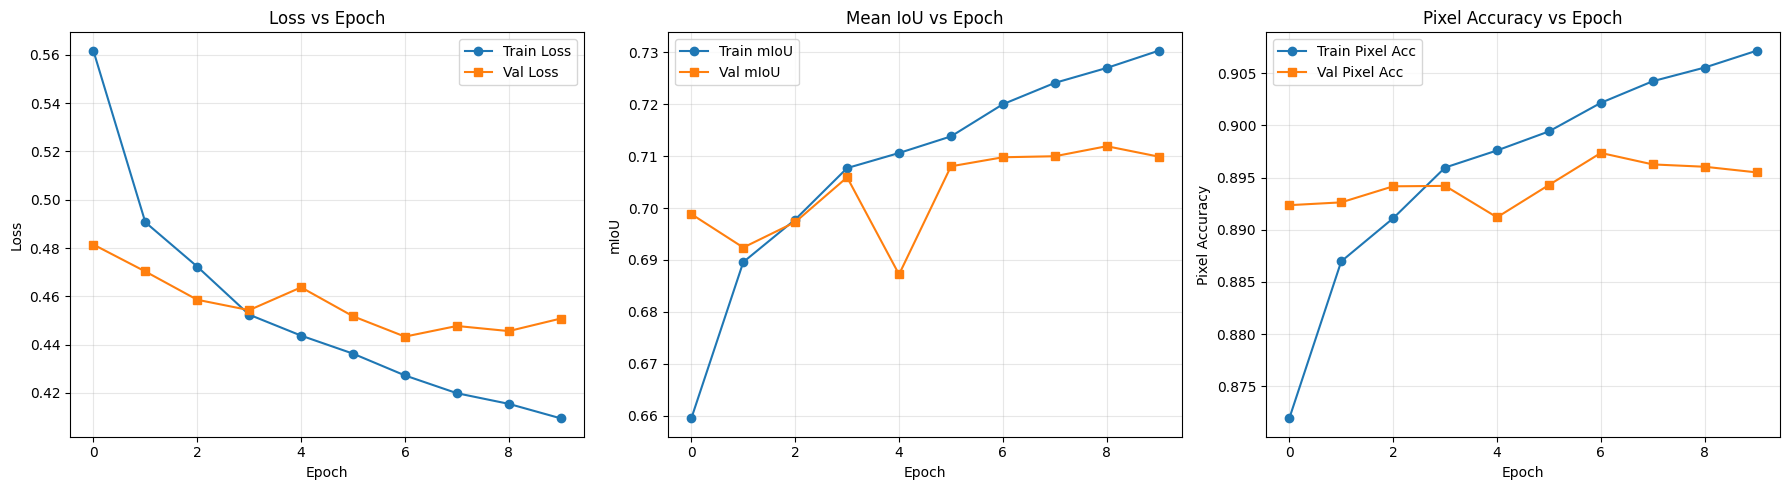


RESULTADOS EN TEST SET
Test Loss: 0.4521
Test mIoU: 0.7168
Test Pixel Accuracy: 0.8965

IoU por clase:
  Clase 0 (Mascota): 0.8140
  Clase 1 (Borde):   0.9029
  Clase 2 (Fondo):   0.4335



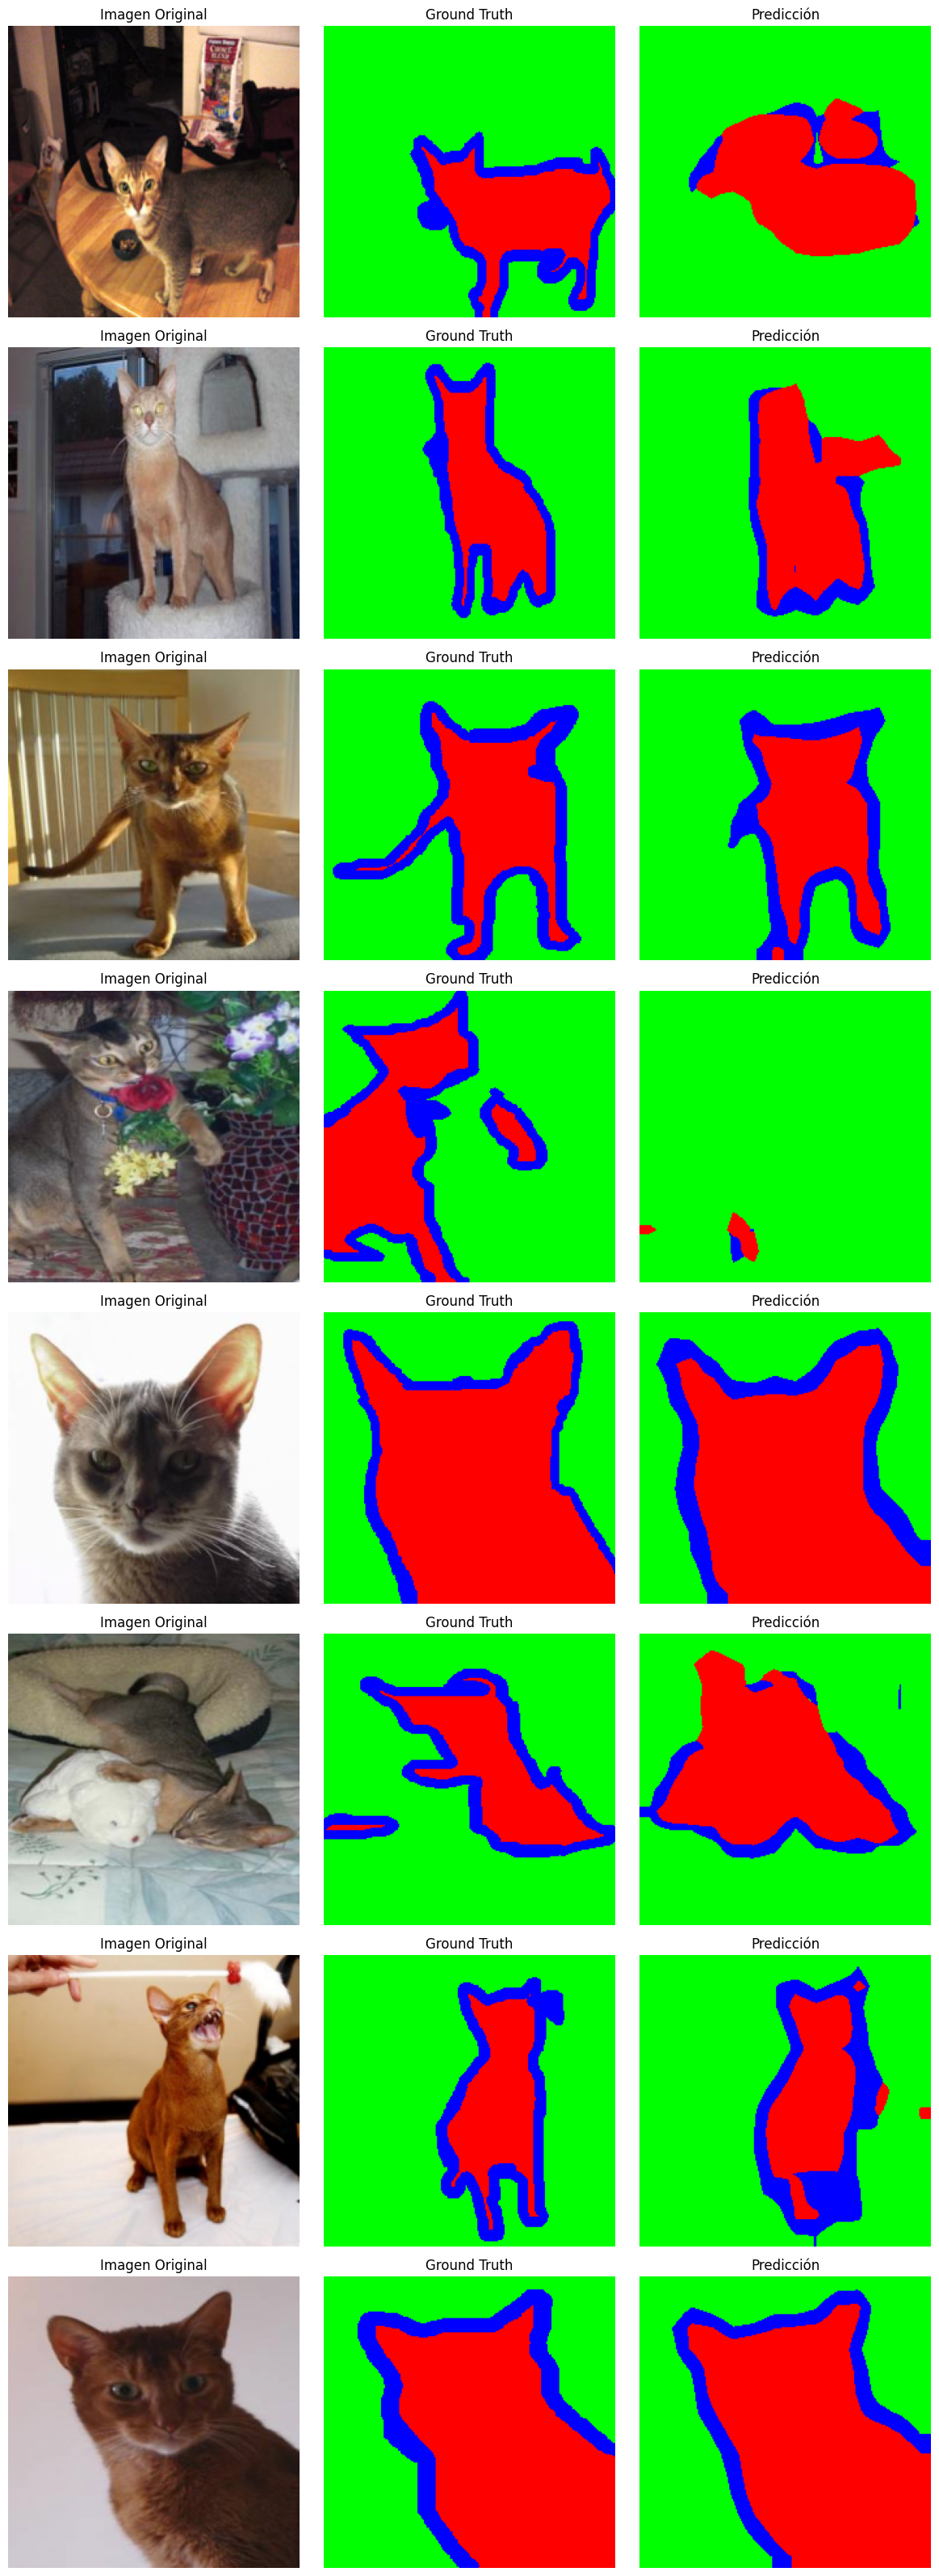

In [10]:
# 9. Evaluación final
plot_training_history(history)

model.load_state_dict(torch.load("best_deeplabv3_oxford_pet_seg.pth", map_location=device))
test_loss, test_miou, test_pixel_acc, test_ious = evaluate(model, test_loader, criterion)

print(f"\n{'='*50}")
print(f"RESULTADOS EN TEST SET")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test mIoU: {test_miou:.4f}")
print(f"Test Pixel Accuracy: {test_pixel_acc:.4f}")
print(f"\nIoU por clase:")
print(f"  Clase 0 (Mascota): {test_ious[0]:.4f}")
print(f"  Clase 1 (Borde):   {test_ious[1]:.4f}")
print(f"  Clase 2 (Fondo):   {test_ious[2]:.4f}")
print(f"{'='*50}\n")

# Visualización de resultados
visualize_segmentation(model, test_loader, n_samples=8)

## Detección de objetos

### 14.1 Concepto central

La detección de objetos de una clase se enfoca en una tarea más específica que la segmentación: en lugar de clasificar cada píxel, el objetivo es **localizar todas las instancias de una única categoría de objeto** mediante cuadros delimitadores (*bounding boxes*).

El modelo no solo responde "¿está el objeto en la imagen?", sino que también responde "¿dónde está?".

Formalmente, la función del modelo es:
$$
f_\theta: \mathbb{R}^{H \times W \times 3} \rightarrow \mathcal{B}
$$
donde:

*   $H, W$: alto y ancho de la imagen.
*   $\mathcal{B} = \{ (b_i, s_i) \}_{i=1}^N$ es un conjunto de $N$ detecciones.
*   $b_i = (x, y, w, h)$ es el cuadro delimitador que define la posición y tamaño del objeto.
*   $s_i \in$ es la puntuación de confianza (*confidence score*) de que la caja $b_i$ contiene una instancia de la clase de interés.
*   $f_\theta$: red neuronal (generalmente convolucional) parametrizada por $\theta$.

#### Flujo general de una CNN para detección de objetos

1.  **Entrada**
    *   Imagen $X \in \mathbb{R}^{H\times W\times 3}$.

2.  **Backbone (Extractor de características)**
    *   Una red convolucional profunda (ej. ResNet, MobileNet, VGG) que actúa como un *encoder*.
    *   Objetivo: generar mapas de características jerárquicos y semánticamente ricos a diferentes escalas.
    *   Resultado: una serie de mapas de características, por ejemplo, $F_1, F_2, ..., F_k$.

3.  **Neck (Cuello - Fusión de características)**
    *   Componente opcional pero muy común que combina mapas de características de diferentes niveles del backbone.
    *   Ejemplos: **FPN (Feature Pyramid Network)**, PANet.
    *   Objetivo: enriquecer las características con información tanto semántica (capas profundas) como espacial (capas superficiales), facilitando la detección de objetos a múltiples escalas.

4.  **Head (Cabezal - Predicción)**
    *   Toma los mapas de características del backbone o del neck y realiza las predicciones finales.
    *   Se divide en dos ramas paralelas:
        *   **Rama de clasificación:** Predice la confianza ($s_i$) de que un cuadro contiene el objeto.
        *   **Rama de regresión:** Ajusta las coordenadas del cuadro delimitador ($b_i$) para que se ajuste mejor al objeto.
    *   Resultado: el conjunto final de detecciones $\mathcal{B}$.

### 14.2 Arquitecturas representativas para detección de objetos

Los modelos de detección se dividen principalmente en dos familias: *one-stage* (de una etapa) y *two-stage* (de dos etapas).

#### Faster R-CNN (Two-Stage Detector)

Propuesto por *Ren et al. (2015)*, es el arquetipo de los detectores de dos etapas, conocidos por su alta precisión.

##### Estructura general

![Faster R-CNN](https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/content/images/2020/09/Fig02-2.jpg)

Funciona en dos fases principales:

1.  **Region Proposal Network (RPN):**
    *   Una pequeña red convolucional que se desliza sobre el mapa de características del backbone.
    *   Propone un conjunto de **regiones de interés (RoIs)**, que son cuadros delimitadores con alta probabilidad de contener *cualquier* objeto (sin importar la clase).
2.  **Detector Head:**
    *   Para cada RoI propuesta, extrae sus características del mapa principal (usando *RoI Align*).
    *   Clasifica la región (en nuestro caso, "objeto" o "fondo") y refina las coordenadas de su cuadro delimitador.

##### Innovaciones técnicas

*   **RPN:** Primera red que aprende a proponer regiones de interés, eliminando cuellos de botella como *Selective Search*.
*   **End-to-end:** Todo el sistema (RPN + detector) se entrena de forma conjunta.

#### YOLO (You Only Look Once - One-Stage Detector)

YOLO, introducido por *Redmon et al. (2016)*, revolucionó la detección de objetos al plantearla como un único problema de regresión, logrando velocidades en tiempo real.

##### Estructura general

![YOLO Architecture](https://www.researchgate.net/publication/371136193/figure/fig4/AS:11431281162670364@1685416794680/YOLO-Full-Model-Architecture.jpg)

1.  La imagen de entrada se divide en una **parrilla (grid) de S×S celdas**.
2.  Cada celda de la parrilla es responsable de predecir:
    *   **B** cuadros delimitadores y sus puntuaciones de confianza.
    *   Probabilidades de clase (en nuestro caso, una sola probabilidad para nuestra clase de interés).
3.  Todas las predicciones se realizan en una **única pasada** por la red.
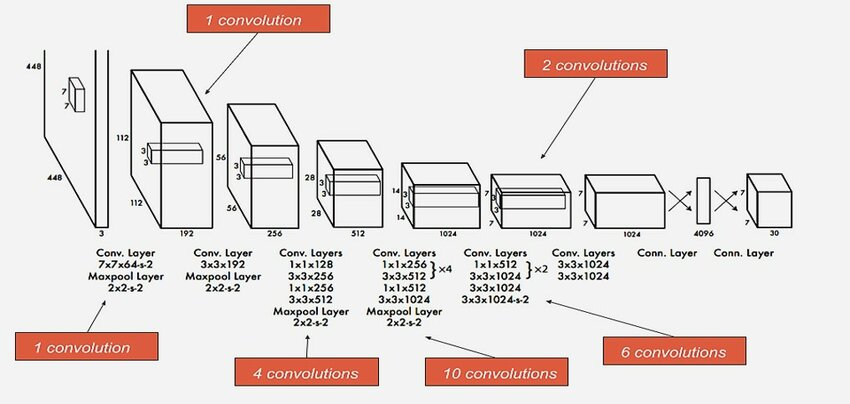
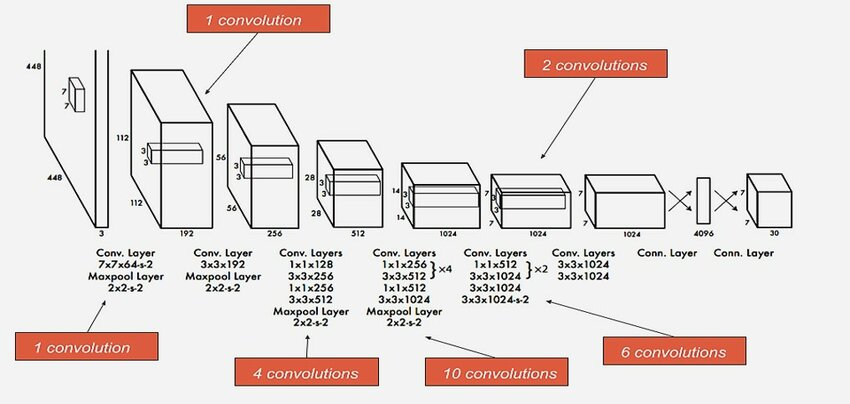

##### Innovaciones técnicas

*   **Detección unificada:** Trata la detección como un problema de regresión directo desde los píxeles de la imagen a las coordenadas y clases.
*   **Velocidad extrema:** Al eliminar la etapa de propuestas de región, es mucho más rápido que los detectores de dos etapas.
*   **Contexto global:** Procesa la imagen completa a la vez, lo que reduce los errores por falsos positivos en el fondo.

#### SSD (Single Shot MultiBox Detector - One-Stage Detector)

SSD, de *Liu et al. (2016)*, ofrece un compromiso entre la velocidad de YOLO y la precisión de Faster R-CNN.

##### Estructura general

![SSD Architecture](https://manalelaidouni.github.io/assets/img/pexels/Image.png)

*   Utiliza un backbone convolucional para generar mapas de características a **diferentes escalas**.
*   Aplica **cabezales de detección** a varios de estos mapas.
    *   Los mapas de capas más profundas (baja resolución) detectan objetos grandes.
    *   Los mapas de capas más superficiales (alta resolución) detectan objetos pequeños.
*   Usa un conjunto de **cajas de anclaje (*anchor boxes*)** predefinidas con diferentes aspect ratios en cada mapa.

##### Innovaciones técnicas

*   **Predicción multiescala:** Es la clave de su precisión, permitiendo detectar objetos de varios tamaños de forma nativa.
*   **Eficiencia:** Mantiene la filosofía de una sola pasada (one-stage) como YOLO.

#### Resumen general

| Arquitectura      | Año  | Principales innovaciones                                             | Ventajas / Desventajas                                    |
| ----------------- | ---- | -------------------------------------------------------------------- | --------------------------------------------------------- |
| **Faster R-CNN**  | 2015 | Region Proposal Network (RPN), entrenamiento end-to-end              | **+** Muy alta precisión<br>**-** Lento                   |
| **YOLO**          | 2016 | Detección unificada, predicción basada en grid                         | **+** Extremadamente rápido<br>**-** Menos preciso en objetos pequeños |
| **SSD**           | 2016 | Detección multiescala desde diferentes capas, uso de anchor boxes      | **+** Buen balance velocidad-precisión<br>**-** Complejo de configurar |

### 14.3 Funciones de pérdida para detección de objetos

En la detección de objetos, la función de pérdida es multifacética, ya que el modelo debe aprender dos tareas simultáneamente: **clasificar** si una región contiene un objeto y **localizar** con precisión dicho objeto. Por ello, la pérdida total es casi siempre una suma ponderada de una pérdida de clasificación ($\mathcal{L}_{cls}$) y una pérdida de localización o regresión ($\mathcal{L}_{loc}$).

$$
\mathcal{L}_{total} = \mathcal{L}_{cls} + \lambda \cdot \mathcal{L}_{loc}
$$

donde $\lambda$ es un hiperparámetro que equilibra la importancia de ambas tareas.

#### Cross-Entropy Loss (para clasificación)

##### Definición

La **Binary Cross-Entropy (BCE)** es el punto de partida para la tarea de clasificación. Para cada caja de anclaje (*anchor box*) propuesta por el modelo, la BCE mide la disimilitud entre la probabilidad predicha de que contenga el objeto de interés y la etiqueta real (1 si es objeto, 0 si es fondo).

$$
\mathcal{L}_{BCE} = - \frac{1}{N} \sum_{i=1}^{N} [y_i \log(p_i) + (1 - y_i) \log(1 - p_i)]
$$

donde:

*   $N$: número total de cajas de anclaje.
*   $y_i \in \{0, 1\}$: etiqueta real de la caja $i$.
*   $p_i$: probabilidad predicha de que la caja $i$ contenga el objeto.

##### Consideraciones

*   Es el estándar para problemas de clasificación binaria y funciona bien en escenarios balanceados.
*   Su principal debilidad en detección es el **desbalance extremo entre clases**. En una imagen típica, el número de cajas de anclaje que corresponden al fondo (negativos) es órdenes de magnitud mayor que las que contienen objetos (positivos).
*   Este desbalance provoca que los **negativos fáciles** (regiones de fondo obvias) dominen el valor de la pérdida y el gradiente, llevando al modelo a aprender a predecir "fondo" de manera muy eficiente, pero descuidando la detección del objeto real.

#### Focal Loss (para clasificación)

##### Definición

La **Focal Loss**, introducida en el paper de RetinaNet, es una modificación de la Cross-Entropy diseñada específicamente para resolver el problema del desbalance de clases. Lo hace reduciendo dinámicamente el peso de los ejemplos que ya están bien clasificados.

$$
\mathcal{L}_{FL}(p_t) = - \alpha_t (1 - p_t)^\gamma \log(p_t)
$$

donde:

*   $p_t$ es la probabilidad predicha para la clase correcta ($p$ si $y=1$, $1-p$ si $y=0$).
*   $\gamma \ge 0$ es el **parámetro de enfoque (focusing parameter)**.
*   $\alpha_t$ es un factor de ponderación para la clase (similar a BCE ponderada).

El término clave es el factor de modulación $(1 - p_t)^\gamma$. Cuando un ejemplo es clasificado correctamente con alta confianza ($p_t \rightarrow 1$), este factor se acerca a cero y la contribución de ese ejemplo a la pérdida se reduce drásticamente.

##### Consideraciones

*   Permite que el entrenamiento se **concentre en los ejemplos difíciles** (ej. objetos pequeños, ocluidos o cajas con bajo IoU) cuya $p_t$ es baja.
*   Para $\gamma=0$, la Focal Loss es equivalente a la Cross-Entropy. A medida que $\gamma$ aumenta (valores típicos son 1 o 2), el efecto de modulación se vuelve más fuerte.
*   Fue la innovación clave que permitió a los detectores de una etapa (one-stage) como RetinaNet superar la precisión de los detectores de dos etapas (two-stage) por primera vez.

#### Smooth L1 Loss (para localización)

##### Definición

Es la función de pérdida tradicionalmente usada para la regresión de las coordenadas del cuadro delimitador. Es una combinación de la pérdida L1 y L2, diseñada para ser menos sensible a outliers que la L2 pero más estable cerca del mínimo que la L1.

$$
\text{Smooth}_{L1}(x) =
\begin{cases}
0.5 x^2 & \text{si } |x| < 1 \\
|x| - 0.5 & \text{en otro caso}
\end{cases}
$$

Se aplica a la diferencia entre el vector de coordenadas predicho $(t_x, t_y, t_w, t_h)$ y el real.

##### Consideraciones

*   Es robusta y ha sido un estándar durante mucho tiempo en arquitecturas como Faster R-CNN.
*   Su principal limitación es que **trata cada coordenada de forma independiente** y no está directamente correlacionada con la métrica de evaluación final, el **IoU**.
*   Una misma magnitud de error (ej. 10 píxeles) en las coordenadas tiene un impacto muy diferente en el IoU si el objeto es grande o pequeño. La pérdida no captura esta relación.

#### IoU-based Losses (para localización)

Estas funciones de pérdida buscan optimizar directamente una métrica relacionada con el IoU, lo que suele llevar a una mejor alineación entre lo que el modelo aprende y cómo se le evalúa.

##### GIoU Loss (Generalized IoU)

##### Definición

La **GIoU Loss** extiende la IoU Loss para resolver el problema de las cajas que no se solapan. Además de maximizar el IoU, minimiza el área de la caja envolvente más pequeña que contiene tanto la predicción como la caja real.

$$
\mathcal{L}_{GIoU} = 1 - \text{GIoU} = 1 - \left( \text{IoU} - \frac{|C \setminus (B_p \cup B_{gt})|}{|C|} \right)
$$

donde:

*   $B_p$ y $B_{gt}$ son las cajas predicha y real.
*   $C$ es la caja convexa más pequeña que encierra a ambas.
*   El término de penalización mide la proporción de área en $C$ que no está ocupada por las dos cajas.

##### Consideraciones

*   A diferencia de la IoU Loss (que es 0 si no hay solapamiento), la GIoU Loss siempre produce un gradiente que empuja a las cajas a acercarse, incluso si están lejos.
*   Funciona como un buen sustituto de la Smooth L1 Loss, correlacionando mejor con la métrica de IoU.
*   Puede tener una convergencia lenta cuando una caja está contenida dentro de la otra.

##### CIoU Loss (Complete IoU)

##### Definición

La **CIoU Loss** es una de las variantes más completas y efectivas. Mejora la GIoU Loss al incorporar dos factores geométricos adicionales: la **distancia entre los centros** de las cajas y la **consistencia de la relación de aspecto**.

$$
\mathcal{L}_{CIoU} = 1 - \text{IoU} + \frac{\rho^2(b_p, b_{gt})}{c^2} + \alpha v
$$

donde:

*   El primer término es la IoU Loss.
*   El segundo término, $\frac{\rho^2}{c^2}$, penaliza la distancia normalizada entre los centros de las cajas.
*   El tercer término, $\alpha v$, penaliza la inconsistencia en la relación de aspecto.

##### Consideraciones

*   Al optimizar simultáneamente el solapamiento, la distancia central y la forma, la CIoU Loss conduce a una convergencia más rápida y a un rendimiento generalmente superior.
*   Es especialmente efectiva para evitar que el modelo produzca cajas con formas extrañas o desplazadas.
*   Se ha convertido en la pérdida de localización por defecto en muchas arquitecturas modernas, como las últimas versiones de YOLO.

#### Resumen general

| Función de pérdida | Tipo          | Enfoca en...                                 | Ventajas                                                 | Limitaciones                                          |
| ------------------ | ------------- | -------------------------------------------- | -------------------------------------------------------- | ----------------------------------------------------- |
| **Cross-Entropy**  | Clasificación | Precisión de la clasificación                | Simple, estándar                                         | Muy sensible al desbalance de clases                  |
| **Focal Loss**     | Clasificación | Ejemplos difíciles y desbalance de clases    | Robusta al desbalance, mejora la precisión del detector  | Requiere ajustar hiperparámetros ($\alpha, \gamma$)   |
| **Smooth L1**      | Localización  | Diferencia de coordenadas                    | Estable y robusta a outliers                             | No correlaciona bien con la métrica de IoU            |
| **GIoU Loss**      | Localización  | Solapamiento y proximidad global             | Proporciona gradiente para cajas no solapadas            | Convergencia lenta en ciertos casos (ej. anidamiento) |
| **CIoU Loss**      | Localización  | Solapamiento, distancia y relación de aspecto | Convergencia rápida, rendimiento superior, estable      | Mayor complejidad en la formulación                   |

### 14.4 Medidas de rendimiento para detección de objetos (metrics)

Evaluar un detector de objetos es más complejo que una simple exactitud. Se basa en el concepto de **Intersection over Union (IoU)**.

#### Intersection over Union (IoU)

Mide el grado de solapamiento entre el cuadro predicho ($B_p$) y el cuadro real ($B_{gt}$).

$$
\text{IoU} = \frac{\text{Area}(B_p \cap B_{gt})}{\text{Area}(B_p \cup B_{gt})}
$$

Un **umbral de IoU** (ej. 0.5) se usa para determinar si una detección es correcta.

*   **True Positive (TP):** Una predicción que se solapa con un cuadro real con un `IoU > umbral`.
*   **False Positive (FP):** Una predicción que no cumple el umbral de IoU con ningún cuadro real.
*   **False Negative (FN):** Un cuadro real que no fue detectado por ninguna predicción.

#### Precision y Recall

*   **Precision:** De todas las predicciones que hizo el modelo, ¿cuántas fueron correctas?
    $$
    \text{Precision} = \frac{TP}{TP + FP}
    $$
*   **Recall (Sensibilidad):** De todos los objetos reales que había, ¿cuántos detectó el modelo?
    $$
    \text{Recall} = \frac{TP}{TP + FN}
    $$

#### Curva Precision-Recall y Average Precision (AP)

Un modelo produce una puntuación de confianza para cada detección. Variando el **umbral de confianza**, obtenemos diferentes pares de (Precision, Recall), que forman la **Curva PR**.

**Average Precision (AP)** es el **área bajo la Curva PR**. Es la métrica estándar para una única clase.

$$
\text{AP} = \int_0^1 p(r) , dr
$$

#### Mean Average Precision (mAP)

*   En la **detección multiclase**, mAP es el promedio del AP calculado para cada clase.
*   En la **detección de una sola clase**, **mAP = AP**.

A menudo se especifica el umbral de IoU usado:

*   **AP@50** o **AP<sub>50</sub>**: AP calculado con un umbral de IoU de 0.5.
*   **AP@75** o **AP<sub>75</sub>**: AP calculado con un umbral de IoU de 0.75.
*   **AP@[.5:.95]** (Métrica COCO): AP promediado sobre 10 umbrales de IoU, desde 0.5 hasta 0.95.

### 14.5 Entrenamiento y uso de la transferencia de aprendizaje

In [16]:
# 1. Configuración general
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [17]:
# 2. Descargar y preparar COCO128 dataset
def download_coco128(root="./data"):
    """Descarga el dataset COCO128 (128 imágenes de COCO)."""
    coco128_path = os.path.join(root, "coco128")
    
    if os.path.exists(coco128_path):
        print("COCO128 ya está descargado.")
        return coco128_path
    
    os.makedirs(root, exist_ok=True)
    
    # URL del dataset COCO128
    url = "https://github.com/ultralytics/yolov5/releases/download/v1.0/coco128.zip"
    zip_path = os.path.join(root, "coco128.zip")
    
    print("Descargando COCO128...")
    urllib.request.urlretrieve(url, zip_path)
    
    print("Extrayendo archivos...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(root)
    
    os.remove(zip_path)
    print("COCO128 descargado y extraído exitosamente.")
    
    return coco128_path

In [18]:
# 3. Dataset personalizado para COCO128
class COCO128Dataset(Dataset):
    """Dataset COCO128 para detección de objetos."""
    
    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        self.imgs_path = os.path.join(root, "images", "train2017")
        self.labels_path = os.path.join(root, "labels", "train2017")
        
        # Obtener lista de imágenes
        self.imgs = sorted([f for f in os.listdir(self.imgs_path) if f.endswith('.jpg')])
        
        # Mapeo de clases COCO (80 clases)
        self.coco_classes = [
            'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 
            'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 
            'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 
            'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 
            'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 
            'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 
            'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 
            'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 
            'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 
            'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 
            'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 
            'toothbrush'
        ]
    
    def __len__(self):
        return len(self.imgs)
    
    def __getitem__(self, idx):
        # Cargar imagen
        img_name = self.imgs[idx]
        img_path = os.path.join(self.imgs_path, img_name)
        img = Image.open(img_path).convert("RGB")
        
        # Cargar anotaciones (formato YOLO)
        label_name = img_name.replace('.jpg', '.txt')
        label_path = os.path.join(self.labels_path, label_name)
        
        boxes = []
        labels = []
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    # Formato YOLO: class x_center y_center width height (normalizados)
                    parts = line.strip().split()
                    if len(parts) == 5:
                        class_id = int(parts[0])
                        x_center, y_center, width, height = map(float, parts[1:])
                        
                        # Convertir de YOLO a formato [x_min, y_min, x_max, y_max]
                        img_width, img_height = img.size
                        x_min = (x_center - width / 2) * img_width
                        y_min = (y_center - height / 2) * img_height
                        x_max = (x_center + width / 2) * img_width
                        y_max = (y_center + height / 2) * img_height
                        
                        boxes.append([x_min, y_min, x_max, y_max])
                        labels.append(class_id + 1)  # +1 porque 0 es background
        
        # Convertir a tensores
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        
        # Si no hay objetos, crear tensores vacíos
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        
        # Crear target
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = torch.tensor([idx])
        
        # Aplicar transformaciones
        if self.transforms:
            img = self.transforms(img)
        
        return img, target

# 4. Transformaciones
def get_transform(train=False):
    """Transformaciones para las imágenes."""
    transforms_list = []
    transforms_list.append(transforms.ToTensor())
    # Faster R-CNN no requiere normalización específica
    return transforms.Compose(transforms_list)

In [19]:
# 5. Descargar dataset y crear DataLoaders
root = "./data"
coco128_path = download_coco128(root)

# Crear datasets
full_dataset = COCO128Dataset(coco128_path, transforms=get_transform(train=True))

# Dividir en train/val/test (70/15/15)
n_total = len(full_dataset)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_ds, val_ds, test_ds = torch.utils.data.random_split(
    full_dataset, 
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(seed)
)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

COCO128 ya está descargado.
Train: 89 | Val: 19 | Test: 20


In [24]:
# 6. Collate function para batch con diferentes números de objetos
def collate_fn(batch):
    """Función personalizada para agrupar imágenes con diferentes números de objetos."""
    return tuple(zip(*batch))

# 7. DataLoaders
batch_size = 4  # Batch pequeño para detección
train_loader = DataLoader(
    train_ds, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=4, 
    collate_fn=collate_fn,
    pin_memory=True
)
val_loader = DataLoader(
    val_ds, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=4, 
    collate_fn=collate_fn,
    pin_memory=True
)
test_loader = DataLoader(
    test_ds, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=4, 
    collate_fn=collate_fn,
    pin_memory=True
)

print("\n Dataset y DataLoaders listos")


 Dataset y DataLoaders listos


In [21]:
# 8. Modelo: Faster R-CNN con MobileNetV3-Large FPN
def get_model(num_classes=81, trainable_backbone_layers=3):
    """
    Crea el modelo Faster R-CNN con MobileNetV3-Large FPN.
    num_classes = 80 clases COCO + 1 background = 81
    """
    model = models.detection.fasterrcnn_mobilenet_v3_large_fpn(
        weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.COCO_V1,
        trainable_backbone_layers=trainable_backbone_layers
    )
    
    # El modelo ya viene con 91 clases de COCO, pero usaremos 81
    # No necesitamos modificar nada si usamos las mismas clases
    
    return model

# Crear modelo
num_classes = 81  # 80 clases COCO + background
model = get_model(num_classes=num_classes, trainable_backbone_layers=3)
model = model.to(device)

print(f" Modelo cargado con {num_classes} clases")

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth
100%|██████████| 74.2M/74.2M [00:00<00:00, 155MB/s] 


 Modelo cargado con 81 clases


In [23]:
# 9. Función de entrenamiento
def train_epoch(model, loader, optimizer, device):
    """Entrena el modelo por una época."""
    model.train()
    total_loss = 0
    loss_classifier_sum = 0
    loss_box_reg_sum = 0
    loss_objectness_sum = 0
    loss_rpn_box_reg_sum = 0
    n_batches = 0
    
    progress_bar = tqdm(loader, desc="Training")
    
    for images, targets in progress_bar:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        # Forward pass
        loss_dict = model(images, targets)
        
        # Calcular pérdida total
        losses = sum(loss for loss in loss_dict.values())
        
        # Backward pass
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        # Acumular pérdidas
        total_loss += losses.item()
        loss_classifier_sum += loss_dict['loss_classifier'].item()
        loss_box_reg_sum += loss_dict['loss_box_reg'].item()
        loss_objectness_sum += loss_dict['loss_objectness'].item()
        loss_rpn_box_reg_sum += loss_dict['loss_rpn_box_reg'].item()
        n_batches += 1
        
        # Actualizar barra de progreso
        progress_bar.set_postfix({
            'loss': f'{losses.item():.4f}'
        })
    
    # Promedios
    avg_loss = total_loss / n_batches
    avg_loss_classifier = loss_classifier_sum / n_batches
    avg_loss_box_reg = loss_box_reg_sum / n_batches
    avg_loss_objectness = loss_objectness_sum / n_batches
    avg_loss_rpn_box_reg = loss_rpn_box_reg_sum / n_batches
    
    return {
        'total_loss': avg_loss,
        'loss_classifier': avg_loss_classifier,
        'loss_box_reg': avg_loss_box_reg,
        'loss_objectness': avg_loss_objectness,
        'loss_rpn_box_reg': avg_loss_rpn_box_reg
    }

# 10. Función de evaluación
@torch.no_grad()
def evaluate(model, loader, device, iou_threshold=0.5):
    """Evalúa el modelo y calcula métricas."""
    model.eval()
    
    all_predictions = []
    all_targets = []
    
    progress_bar = tqdm(loader, desc="Evaluating")
    
    for images, targets in progress_bar:
        images = list(image.to(device) for image in images)
        
        # Predicciones
        predictions = model(images)
        
        # Mover a CPU
        predictions = [{k: v.cpu() for k, v in pred.items()} for pred in predictions]
        targets = [{k: v.cpu() for k, v in t.items()} for t in targets]
        
        all_predictions.extend(predictions)
        all_targets.extend(targets)
    
    # Calcular mAP simplificado
    map_score = compute_map(all_predictions, all_targets, iou_threshold=iou_threshold)
    
    return map_score, all_predictions, all_targets

In [25]:
# 11. Cálculo de mAP (Mean Average Precision)
def compute_iou_boxes(box1, box2):
    """Calcula IoU entre dos bounding boxes."""
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2
    
    # Intersección
    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)
    
    inter_area = max(0, inter_x_max - inter_x_min) * max(0, inter_y_max - inter_y_min)
    
    # Unión
    box1_area = (x1_max - x1_min) * (y1_max - y1_min)
    box2_area = (x2_max - x2_min) * (y2_max - y2_min)
    union_area = box1_area + box2_area - inter_area
    
    if union_area == 0:
        return 0.0
    
    return inter_area / union_area

def compute_map(predictions, targets, iou_threshold=0.5, score_threshold=0.5):
    """Calcula mAP simplificado."""
    total_tp = 0
    total_fp = 0
    total_fn = 0
    
    for pred, target in zip(predictions, targets):
        pred_boxes = pred['boxes']
        pred_labels = pred['labels']
        pred_scores = pred['scores']
        
        target_boxes = target['boxes']
        target_labels = target['labels']
        
        # Filtrar predicciones por score
        mask = pred_scores > score_threshold
        pred_boxes = pred_boxes[mask]
        pred_labels = pred_labels[mask]
        pred_scores = pred_scores[mask]
        
        matched_targets = set()
        
        # Para cada predicción
        for pred_box, pred_label in zip(pred_boxes, pred_labels):
            best_iou = 0
            best_idx = -1
            
            # Buscar el mejor match con targets
            for idx, (target_box, target_label) in enumerate(zip(target_boxes, target_labels)):
                if idx in matched_targets:
                    continue
                
                if pred_label == target_label:
                    iou = compute_iou_boxes(pred_box, target_box)
                    if iou > best_iou:
                        best_iou = iou
                        best_idx = idx
            
            # Clasificar como TP o FP
            if best_iou >= iou_threshold:
                total_tp += 1
                matched_targets.add(best_idx)
            else:
                total_fp += 1
        
        # False Negatives: targets no matcheados
        total_fn += len(target_boxes) - len(matched_targets)
    
    # Calcular métricas
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'tp': total_tp,
        'fp': total_fp,
        'fn': total_fn
    }

In [26]:
# 12. Entrenamiento
n_epochs = 10
best_f1 = 0.0

# Optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# Learning rate scheduler
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Historial
history = {
    'train_loss': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': []
}

print("\n" + "="*80)
print("INICIANDO ENTRENAMIENTO - DETECCIÓN DE OBJETOS")
print("="*80 + "\n")

for epoch in range(n_epochs):
    print(f"\nEpoch {epoch+1}/{n_epochs}")
    print("-" * 50)
    
    # Entrenar
    train_losses = train_epoch(model, train_loader, optimizer, device)
    
    # Validar
    val_metrics, _, _ = evaluate(model, val_loader, device, iou_threshold=0.5)
    
    # Actualizar learning rate
    lr_scheduler.step()
    
    # Guardar historial
    history['train_loss'].append(train_losses['total_loss'])
    history['val_precision'].append(val_metrics['precision'])
    history['val_recall'].append(val_metrics['recall'])
    history['val_f1'].append(val_metrics['f1_score'])
    
    # Imprimir resultados
    print(f"\nTrain Loss: {train_losses['total_loss']:.4f}")
    print(f"  - Classifier: {train_losses['loss_classifier']:.4f}")
    print(f"  - Box Reg: {train_losses['loss_box_reg']:.4f}")
    print(f"  - Objectness: {train_losses['loss_objectness']:.4f}")
    print(f"  - RPN Box Reg: {train_losses['loss_rpn_box_reg']:.4f}")
    
    print(f"\nVal Metrics:")
    print(f"  - Precision: {val_metrics['precision']:.4f}")
    print(f"  - Recall: {val_metrics['recall']:.4f}")
    print(f"  - F1-Score: {val_metrics['f1_score']:.4f}")
    print(f"  - TP: {val_metrics['tp']}, FP: {val_metrics['fp']}, FN: {val_metrics['fn']}")
    
    # Guardar mejor modelo
    if val_metrics['f1_score'] > best_f1:
        best_f1 = val_metrics['f1_score']
        torch.save(model.state_dict(), "best_fasterrcnn_coco128.pth")
        print("\n  → Modelo mejorado guardado ✓")

print("\n" + "="*80)
print("ENTRENAMIENTO COMPLETADO")
print("="*80 + "\n")


INICIANDO ENTRENAMIENTO - DETECCIÓN DE OBJETOS


Epoch 1/10
--------------------------------------------------


Evaluating: 100%|██████████| 5/5 [00:00<00:00,  5.71it/s]



Train Loss: 1.5329
  - Classifier: 1.0271
  - Box Reg: 0.3684
  - Objectness: 0.0579
  - RPN Box Reg: 0.0795

Val Metrics:
  - Precision: 0.7576
  - Recall: 0.1462
  - F1-Score: 0.2451
  - TP: 25, FP: 8, FN: 146

  → Modelo mejorado guardado ✓

Epoch 2/10
--------------------------------------------------


Evaluating: 100%|██████████| 5/5 [00:00<00:00,  5.50it/s]



Train Loss: 1.1474
  - Classifier: 0.7162
  - Box Reg: 0.3058
  - Objectness: 0.0500
  - RPN Box Reg: 0.0754

Val Metrics:
  - Precision: 0.5614
  - Recall: 0.1871
  - F1-Score: 0.2807
  - TP: 32, FP: 25, FN: 139

  → Modelo mejorado guardado ✓

Epoch 3/10
--------------------------------------------------


...


Train Loss: 0.6484
  - Classifier: 0.3776
  - Box Reg: 0.2110
  - Objectness: 0.0229
  - RPN Box Reg: 0.0370

Val Metrics:
  - Precision: 0.4627
  - Recall: 0.1813
  - F1-Score: 0.2605
  - TP: 31, FP: 36, FN: 140

Epoch 9/10
--------------------------------------------------


Evaluating: 100%|██████████| 5/5 [00:00<00:00,  5.69it/s]



Train Loss: 0.6364
  - Classifier: 0.3688
  - Box Reg: 0.2095
  - Objectness: 0.0213
  - RPN Box Reg: 0.0368

Val Metrics:
  - Precision: 0.4706
  - Recall: 0.1871
  - F1-Score: 0.2678
  - TP: 32, FP: 36, FN: 139

Epoch 10/10
--------------------------------------------------


Evaluating: 100%|██████████| 5/5 [00:00<00:00,  5.68it/s]


Train Loss: 0.6178
  - Classifier: 0.3558
  - Box Reg: 0.2024
  - Objectness: 0.0219
  - RPN Box Reg: 0.0377

Val Metrics:
  - Precision: 0.4706
  - Recall: 0.1871
  - F1-Score: 0.2678
  - TP: 32, FP: 36, FN: 139

ENTRENAMIENTO COMPLETADO



Evaluando en test set...


Evaluating: 100%|██████████| 5/5 [00:00<00:00,  5.17it/s]



RESULTADOS EN TEST SET
Precision: 0.5217
Recall: 0.2017
F1-Score: 0.2909
TP: 24, FP: 22, FN: 95

Entrenamiento y evaluación completados

GENERANDO VISUALIZACIONES



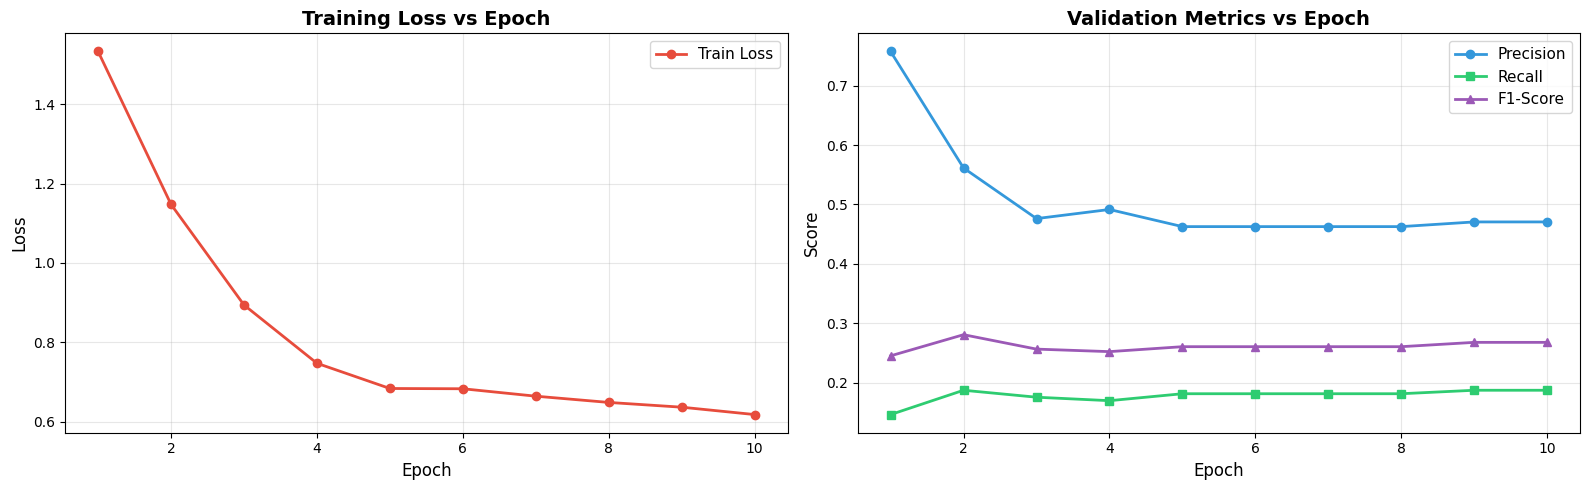

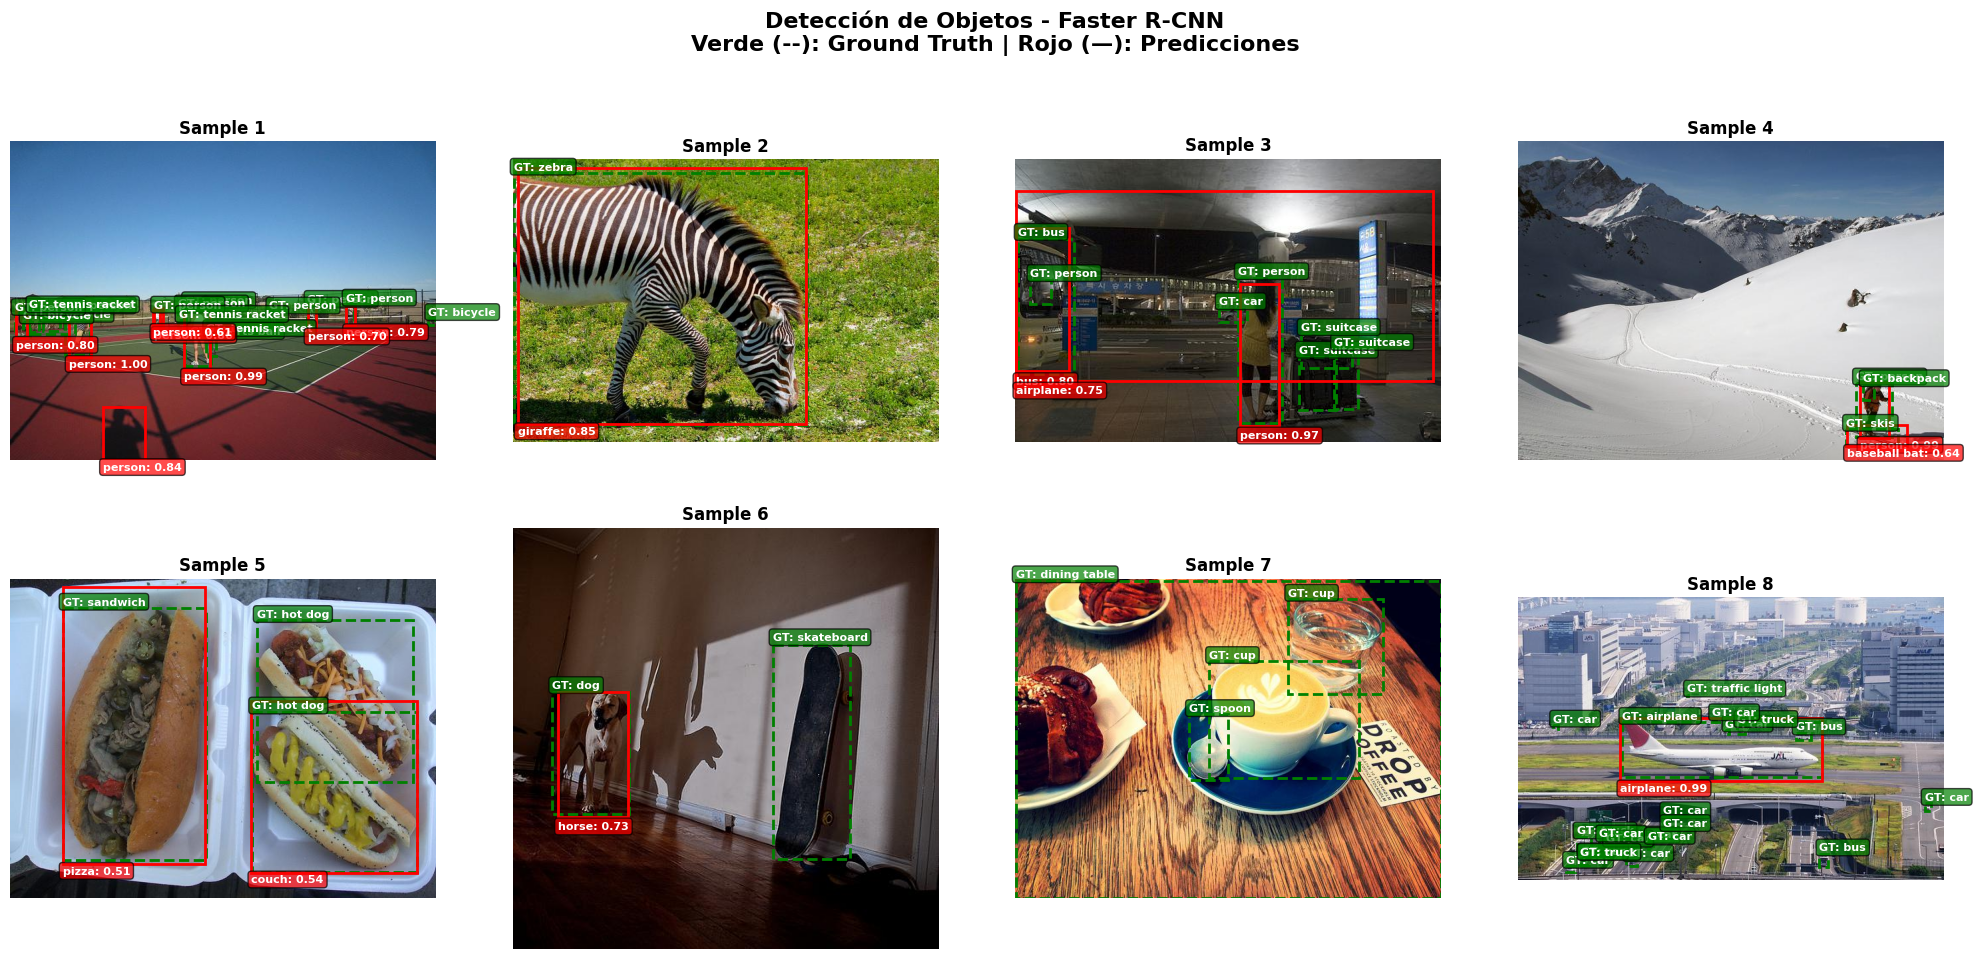


ANÁLISIS POR CLASE
Clase                Ground Truth    Predicciones   
--------------------------------------------------------------------------------
person               25              23             
bicycle              3               0              
car                  22              2              
airplane             3               3              
bus                  3               1              
truck                3               1              
traffic light        1               0              
bench                1               0              
dog                  2               1              
horse                0               1              
elephant             2               0              
zebra                1               0              
giraffe              7               1              
backpack             3               4              
handbag              1               1              
tie                  2               0             

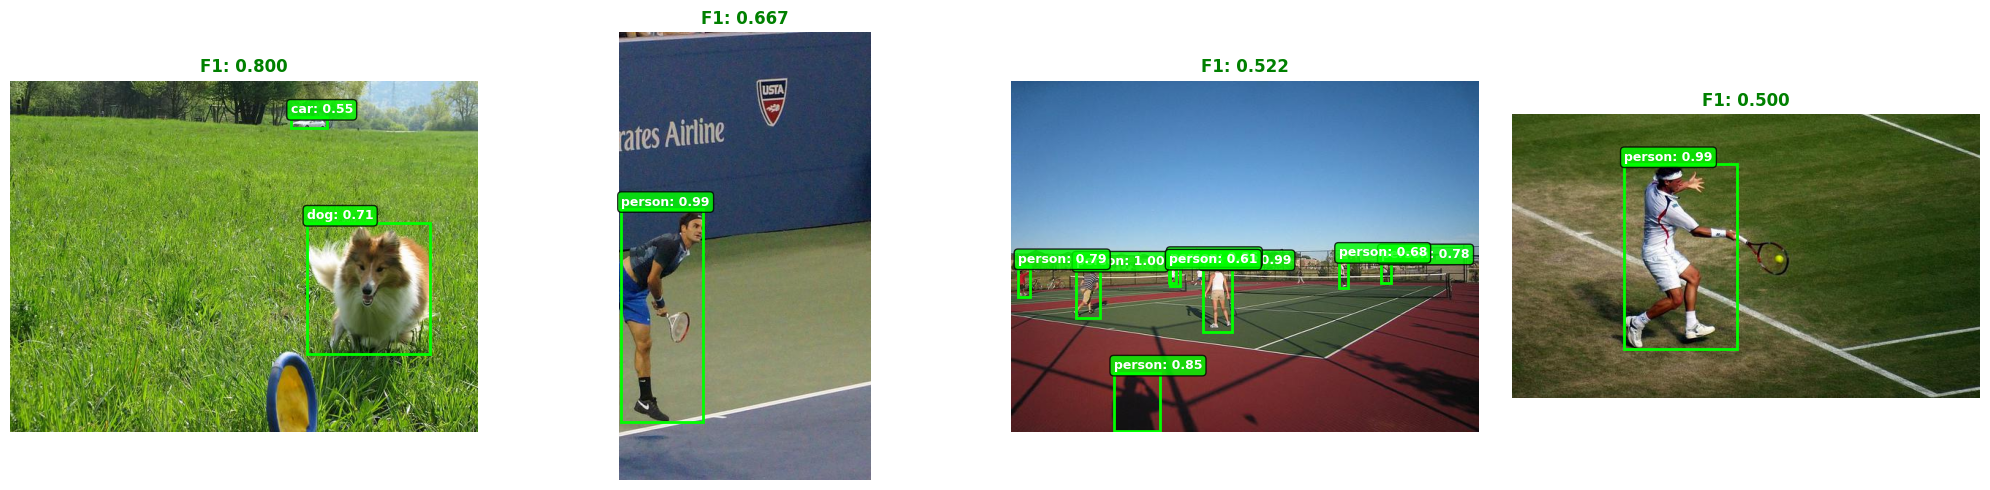


PEORES DETECCIONES (Menor F1-Score)


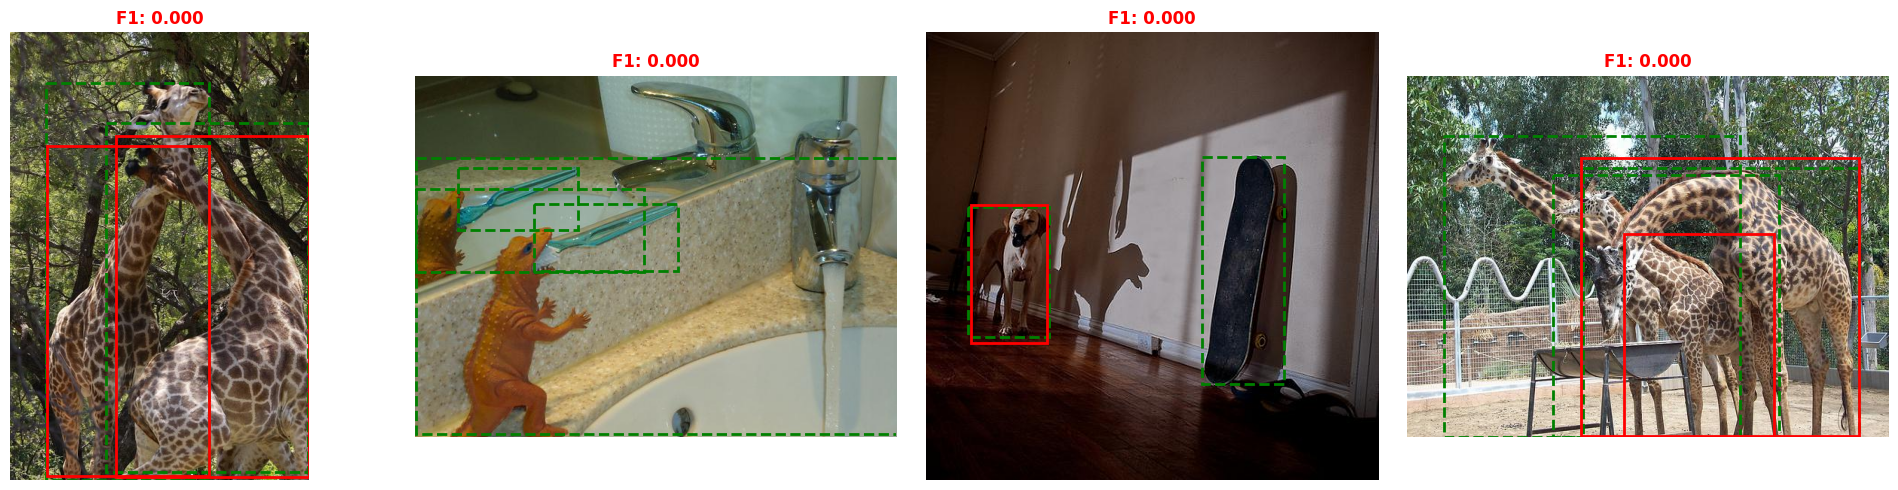


 TODAS LAS VISUALIZACIONES COMPLETADAS



In [29]:
# 13. Evaluación final en test
print("Evaluando en test set...")
model.load_state_dict(torch.load("best_fasterrcnn_coco128.pth", map_location=device))
test_metrics, test_predictions, test_targets = evaluate(model, test_loader, device, iou_threshold=0.5)

print(f"\n{'='*50}")
print(f"RESULTADOS EN TEST SET")
print(f"{'='*50}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall: {test_metrics['recall']:.4f}")
print(f"F1-Score: {test_metrics['f1_score']:.4f}")
print(f"TP: {test_metrics['tp']}, FP: {test_metrics['fp']}, FN: {test_metrics['fn']}")
print(f"{'='*50}\n")

print("Entrenamiento y evaluación completados")

# 14. Función para graficar historial de entrenamiento
def plot_training_history(history):
    """Grafica métricas de entrenamiento vs época."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    axes[0].plot(epochs, history['train_loss'], label='Train Loss', marker='o', linewidth=2, color='#e74c3c')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training Loss vs Epoch', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Métricas de validación
    axes[1].plot(epochs, history['val_precision'], label='Precision', marker='o', linewidth=2, color='#3498db')
    axes[1].plot(epochs, history['val_recall'], label='Recall', marker='s', linewidth=2, color='#2ecc71')
    axes[1].plot(epochs, history['val_f1'], label='F1-Score', marker='^', linewidth=2, color='#9b59b6')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Score', fontsize=12)
    axes[1].set_title('Validation Metrics vs Epoch', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 15. Función para visualizar detecciones
def visualize_detections(model, dataset, device, n_samples=8, score_threshold=0.5):
    """Visualiza detecciones del modelo."""
    model.eval()
    
    # Obtener clases COCO
    coco_classes = dataset.dataset.coco_classes if hasattr(dataset, 'dataset') else dataset.coco_classes
    
    # Seleccionar muestras aleatorias
    indices = random.sample(range(len(dataset)), min(n_samples, len(dataset)))
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    with torch.no_grad():
        for idx, sample_idx in enumerate(indices):
            if idx >= 8:
                break
            
            # Obtener imagen y target
            if hasattr(dataset, 'dataset'):
                # Es un Subset
                real_idx = dataset.indices[sample_idx]
                img, target = dataset.dataset[real_idx]
            else:
                img, target = dataset[sample_idx]
            
            # Predicción
            img_tensor = img.to(device)
            prediction = model([img_tensor])[0]
            
            # Convertir imagen a numpy
            img_np = img.permute(1, 2, 0).cpu().numpy()
            
            # Dibujar
            ax = axes[idx]
            ax.imshow(img_np)
            
            # Dibujar ground truth (verde)
            gt_boxes = target['boxes'].cpu().numpy()
            gt_labels = target['labels'].cpu().numpy()
            
            for box, label in zip(gt_boxes, gt_labels):
                x_min, y_min, x_max, y_max = box
                width = x_max - x_min
                height = y_max - y_min
                
                rect = patches.Rectangle(
                    (x_min, y_min), width, height,
                    linewidth=2, edgecolor='green', facecolor='none', linestyle='--'
                )
                ax.add_patch(rect)
                
                # Etiqueta
                class_name = coco_classes[label - 1] if label > 0 else 'background'
                ax.text(
                    x_min, y_min - 5, f'GT: {class_name}',
                    color='white', fontsize=8, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='green', alpha=0.7)
                )
            
            # Dibujar predicciones (rojo)
            pred_boxes = prediction['boxes'].cpu().numpy()
            pred_labels = prediction['labels'].cpu().numpy()
            pred_scores = prediction['scores'].cpu().numpy()
            
            for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
                if score < score_threshold:
                    continue
                
                x_min, y_min, x_max, y_max = box
                width = x_max - x_min
                height = y_max - y_min
                
                rect = patches.Rectangle(
                    (x_min, y_min), width, height,
                    linewidth=2, edgecolor='red', facecolor='none'
                )
                ax.add_patch(rect)
                
                # Etiqueta
                class_name = coco_classes[label - 1] if label > 0 else 'background'
                ax.text(
                    x_min, y_max + 15, f'{class_name}: {score:.2f}',
                    color='white', fontsize=8, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.7)
                )
            
            ax.axis('off')
            ax.set_title(f'Sample {idx + 1}', fontsize=12, fontweight='bold')
    
    # Leyenda
    fig.suptitle(
        'Detección de Objetos - Faster R-CNN\n' +
        'Verde (--): Ground Truth | Rojo (—): Predicciones',
        fontsize=16, fontweight='bold', y=0.98
    )
    
    plt.tight_layout()
    plt.show()

# 16. Función para analizar detecciones por clase
def analyze_detections_by_class(predictions, targets, coco_classes, score_threshold=0.5):
    """Analiza el rendimiento por clase."""
    class_stats = {}
    
    for pred, target in zip(predictions, targets):
        pred_boxes = pred['boxes']
        pred_labels = pred['labels']
        pred_scores = pred['scores']
        
        target_boxes = target['boxes']
        target_labels = target['labels']
        
        # Filtrar predicciones por score
        mask = pred_scores > score_threshold
        pred_boxes = pred_boxes[mask]
        pred_labels = pred_labels[mask]
        
        # Contar por clase
        for label in target_labels:
            label_item = label.item()
            if label_item not in class_stats:
                class_stats[label_item] = {'gt': 0, 'pred': 0, 'tp': 0}
            class_stats[label_item]['gt'] += 1
        
        for label in pred_labels:
            label_item = label.item()
            if label_item not in class_stats:
                class_stats[label_item] = {'gt': 0, 'pred': 0, 'tp': 0}
            class_stats[label_item]['pred'] += 1
    
    # Crear tabla de resultados
    print("\n" + "="*80)
    print("ANÁLISIS POR CLASE")
    print("="*80)
    print(f"{'Clase':<20} {'Ground Truth':<15} {'Predicciones':<15}")
    print("-"*80)
    
    for label_id in sorted(class_stats.keys()):
        class_name = coco_classes[label_id - 1] if label_id > 0 else 'background'
        gt_count = class_stats[label_id]['gt']
        pred_count = class_stats[label_id]['pred']
        print(f"{class_name:<20} {gt_count:<15} {pred_count:<15}")
    
    print("="*80 + "\n")

# 17. Función para visualizar ejemplos de mejor y peor rendimiento
def visualize_best_worst_detections(model, dataset, device, predictions, targets, n_samples=4, score_threshold=0.5):
    """Visualiza las mejores y peores detecciones."""
    model.eval()
    
    # Calcular F1-score por imagen
    image_scores = []
    
    for idx, (pred, target) in enumerate(zip(predictions, targets)):
        pred_boxes = pred['boxes']
        pred_labels = pred['labels']
        pred_scores = pred['scores']
        
        target_boxes = target['boxes']
        target_labels = target['labels']
        
        # Filtrar predicciones
        mask = pred_scores > score_threshold
        pred_boxes = pred_boxes[mask]
        pred_labels = pred_labels[mask]
        
        # Calcular TP, FP, FN
        tp = 0
        matched_targets = set()
        
        for pred_box, pred_label in zip(pred_boxes, pred_labels):
            for t_idx, (target_box, target_label) in enumerate(zip(target_boxes, target_labels)):
                if t_idx in matched_targets:
                    continue
                if pred_label == target_label:
                    iou = compute_iou_boxes(pred_box, target_box)
                    if iou >= 0.5:
                        tp += 1
                        matched_targets.add(t_idx)
                        break
        
        fp = len(pred_boxes) - tp
        fn = len(target_boxes) - tp
        
        # F1-score
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        image_scores.append((idx, f1))
    
    # Ordenar por F1-score
    image_scores.sort(key=lambda x: x[1], reverse=True)
    
    # Mejores y peores
    best_indices = [idx for idx, _ in image_scores[:n_samples]]
    worst_indices = [idx for idx, _ in image_scores[-n_samples:]]
    
    # Obtener clases COCO
    coco_classes = dataset.dataset.coco_classes if hasattr(dataset, 'dataset') else dataset.coco_classes
    
    # Visualizar mejores
    print("\n" + "="*80)
    print("MEJORES DETECCIONES (Mayor F1-Score)")
    print("="*80)
    
    fig, axes = plt.subplots(1, n_samples, figsize=(5*n_samples, 5))
    if n_samples == 1:
        axes = [axes]
    
    for ax_idx, img_idx in enumerate(best_indices):
        if hasattr(dataset, 'dataset'):
            real_idx = dataset.indices[img_idx]
            img, target = dataset.dataset[real_idx]
        else:
            img, target = dataset[img_idx]
        
        pred = predictions[img_idx]
        
        img_np = img.permute(1, 2, 0).cpu().numpy()
        ax = axes[ax_idx]
        ax.imshow(img_np)
        
        # Dibujar predicciones
        pred_boxes = pred['boxes'].cpu().numpy()
        pred_labels = pred['labels'].cpu().numpy()
        pred_scores = pred['scores'].cpu().numpy()
        
        for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
            if score < score_threshold:
                continue
            
            x_min, y_min, x_max, y_max = box
            width = x_max - x_min
            height = y_max - y_min
            
            rect = patches.Rectangle(
                (x_min, y_min), width, height,
                linewidth=2, edgecolor='lime', facecolor='none'
            )
            ax.add_patch(rect)
            
            class_name = coco_classes[label - 1] if label > 0 else 'bg'
            ax.text(
                x_min, y_min - 5, f'{class_name}: {score:.2f}',
                color='white', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lime', alpha=0.8)
            )
        
        ax.axis('off')
        f1_score = image_scores[ax_idx][1]
        ax.set_title(f'F1: {f1_score:.3f}', fontsize=12, fontweight='bold', color='green')
    
    plt.tight_layout()
    plt.show()
    
    # Visualizar peores
    print("\n" + "="*80)
    print("PEORES DETECCIONES (Menor F1-Score)")
    print("="*80)
    
    fig, axes = plt.subplots(1, n_samples, figsize=(5*n_samples, 5))
    if n_samples == 1:
        axes = [axes]
    
    for ax_idx, img_idx in enumerate(worst_indices):
        if hasattr(dataset, 'dataset'):
            real_idx = dataset.indices[img_idx]
            img, target = dataset.dataset[real_idx]
        else:
            img, target = dataset[img_idx]
        
        pred = predictions[img_idx]
        
        img_np = img.permute(1, 2, 0).cpu().numpy()
        ax = axes[ax_idx]
        ax.imshow(img_np)
        
        # Dibujar ground truth (verde) y predicciones (rojo)
        gt_boxes = target['boxes'].cpu().numpy()
        gt_labels = target['labels'].cpu().numpy()
        
        for box, label in zip(gt_boxes, gt_labels):
            x_min, y_min, x_max, y_max = box
            width = x_max - x_min
            height = y_max - y_min
            
            rect = patches.Rectangle(
                (x_min, y_min), width, height,
                linewidth=2, edgecolor='green', facecolor='none', linestyle='--'
            )
            ax.add_patch(rect)
        
        pred_boxes = pred['boxes'].cpu().numpy()
        pred_labels = pred['labels'].cpu().numpy()
        pred_scores = pred['scores'].cpu().numpy()
        
        for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
            if score < score_threshold:
                continue
            
            x_min, y_min, x_max, y_max = box
            width = x_max - x_min
            height = y_max - y_min
            
            rect = patches.Rectangle(
                (x_min, y_min), width, height,
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)
        
        ax.axis('off')
        f1_score = [score for idx, score in image_scores if idx == img_idx][0]
        ax.set_title(f'F1: {f1_score:.3f}', fontsize=12, fontweight='bold', color='red')
    
    plt.tight_layout()
    plt.show()

# 18. Ejecutar visualizaciones
print("\n" + "="*80)
print("GENERANDO VISUALIZACIONES")
print("="*80 + "\n")

# Gráfica de entrenamiento
plot_training_history(history)

# Visualizar detecciones en test
visualize_detections(model, test_ds, device, n_samples=8, score_threshold=0.5)

# Análisis por clase
analyze_detections_by_class(test_predictions, test_targets, full_dataset.coco_classes, score_threshold=0.5)

# Mejores y peores detecciones
visualize_best_worst_detections(
    model, test_ds, device, test_predictions, test_targets, 
    n_samples=4, score_threshold=0.5
)

print("\n" + "="*80)
print(" TODAS LAS VISUALIZACIONES COMPLETADAS")
print("="*80 + "\n")